In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
import tqdm
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import numpy as np

In [4]:
import pandas as pd
import seaborn as sns
sns.set_context('talk')
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde, norm
import tqdm
import textwrap
import warnings
warnings.filterwarnings('ignore')

import time_normalization_helpers

# Comparing TREBL Experiment to barcodes in step 1 map corresponding to empty ADs

In [4]:
con = duckdb.connect("../../../duckdb/ChopTFs_pipeline_step1_empty_ADs.db")
con

In [5]:
tables = con.execute("SHOW ALL TABLES").fetchdf()
tables

,database,schema,name,column_names,column_types,temporary
0,ChopTFs_pipeline_step1_empty_ADs,main,design,[AD],[VARCHAR],False
1,ChopTFs_pipeline_step1_empty_ADs,main,step1_AD_AD_BC_RPTR_BC_barcode_exists,"[AD, AD_BC, RPTR_BC, count, AD_qual, AD_BC_qua...","[VARCHAR, VARCHAR, VARCHAR, BIGINT, BOOLEAN, B...",False
2,ChopTFs_pipeline_step1_empty_ADs,main,step1_AD_AD_BC_RPTR_BC_designed,"[AD, AD_BC, RPTR_BC, count, AD_qual, AD_BC_qua...","[VARCHAR, VARCHAR, VARCHAR, BIGINT, BOOLEAN, B...",False
3,ChopTFs_pipeline_step1_empty_ADs,main,step1_AD_AD_BC_RPTR_BC_initial,"[AD, AD_qual, AD_BC, AD_BC_qual, RPTR_BC, RPTR...","[VARCHAR, BOOLEAN, VARCHAR, BOOLEAN, VARCHAR, ...",False
4,ChopTFs_pipeline_step1_empty_ADs,main,step1_AD_AD_BC_RPTR_BC_initial_grouped,"[AD, AD_BC, RPTR_BC, count, AD_qual, AD_BC_qua...","[VARCHAR, VARCHAR, VARCHAR, BIGINT, BOOLEAN, B...",False
5,ChopTFs_pipeline_step1_empty_ADs,main,step1_AD_AD_BC_RPTR_BC_loss_summary,"[map, description, unique_count, unique_AD_cou...","[VARCHAR, VARCHAR, BIGINT, BIGINT, DOUBLE, DOU...",False
6,ChopTFs_pipeline_step1_empty_ADs,main,step1_AD_AD_BC_RPTR_BC_quality,"[AD, AD_BC, RPTR_BC, count, AD_qual, AD_BC_qua...","[VARCHAR, VARCHAR, VARCHAR, BIGINT, BOOLEAN, B...",False
7,ChopTFs_pipeline_step1_empty_ADs,main,step1_AD_AD_BC_RPTR_BC_thresholded,"[AD, AD_BC, RPTR_BC, count, AD_qual, AD_BC_qua...","[VARCHAR, VARCHAR, VARCHAR, BIGINT, BOOLEAN, B...",False
8,ChopTFs_pipeline_step1_empty_ADs,main,step1_AD_AD_BC_RPTR_BC_unique_target,"[AD, AD_BC, RPTR_BC, count, AD_qual, AD_BC_qua...","[VARCHAR, VARCHAR, VARCHAR, BIGINT, BOOLEAN, B...",False


In [6]:
tables[tables["name"].str.contains("designed")]

,database,schema,name,column_names,column_types,temporary
2,ChopTFs_pipeline_step1_empty_ADs,main,step1_AD_AD_BC_RPTR_BC_designed,"[AD, AD_BC, RPTR_BC, count, AD_qual, AD_BC_qua...","[VARCHAR, VARCHAR, VARCHAR, BIGINT, BOOLEAN, B...",False


In [7]:
empty_AD_controls = con.execute("SELECT * FROM step1_AD_AD_BC_RPTR_BC_quality").fetchdf()
empty_AD_controls.sort_values(by = 'count')

,AD,AD_BC,RPTR_BC,count,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed
469,,GAGCCGTGTCC,CACTTACCAGTAGT,51,True,True,True,0
482,,TGGTGCACGAA,CACTAGATTTGGAC,51,True,True,True,0
481,,CCTGGACCGTT,AGCAAGCCTGTCCA,51,True,True,True,0
480,,GCGAGCCCGCC,CTCCAGATGGCTGT,51,True,True,True,0
479,,AGTCTCACCCG,GTTTACCTAAATTA,51,True,True,True,0
...,...,...,...,...,...,...,...,...
4509,,ACTTCTGAATC,CGAAATATGAGGAG,3335,True,True,True,0
4508,,AGATCTACAGT,AGCACCTTCTGAGA,3761,True,True,True,0
4507,,TTCCACACCAC,TTGCAAGGATTTCA,5278,True,True,True,0
4506,,ACACCAATTAC,TAGAACTATTGCTA,5698,True,True,True,0


In [8]:
empty_AD_controls = empty_AD_controls[["AD_BC", "RPTR_BC"]]
empty_AD_controls

,AD_BC,RPTR_BC
0,ACCTGGCTTTG,TAACCTACTACCCC
1,GTTTGGATGCC,AGCTGATAAAAATA
2,TCGCGTTATTG,CGGCAACGTCCCGG
3,AATGAGGGCGG,TCAGGCCAAAAAGA
4,GATGAAGCACT,TTGTCATTCTATCA
...,...,...
7570,AATGGTACTTG,GGGACCGTTGTAAA
7571,TAGGAAGGTGC,GAAGCCAACGGCAA
7572,TAATCCAGACT,CAATCGATAATCGA
7573,TGAGAGGTAGT,ATACCCTTTTGCCT


# Merging to TREBL experiment

In [9]:
merged_AD_df = pd.read_csv("../../../output/ChopTFs_pipeline/AD_trebl_experiment_results.csv")

In [10]:
merged_RT_df = pd.read_csv("../../../output/ChopTFs_pipeline/RT_trebl_experiment_results.csv")

In [11]:
merged_AD_df = merged_AD_df.drop(columns = "Unnamed: 0").drop_duplicates()
merged_AD_df

,AD_end,AD_BC,count_simple,file_base_simple,gene,rep,time,count_directional,file_base_directional,count_diff
0,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCA,GGCAAAACTCT,22224,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCAGGCAAA...,4,50,21126,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,1098
1,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAA,CAGTTTAGCTA,18886,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAACAGTTT...,4,50,18062,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,824
2,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACT,TGTCCTTGTCG,16525,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACTTGTCCT...,4,50,15886,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,639
3,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTT,GCCATATAGGT,15934,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTTGCCATA...,4,50,15291,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,643
4,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCA,CTCACCTGCCC,13390,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCACTCACC...,4,50,12912,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,478
...,...,...,...,...,...,...,...,...,...,...
9978655,TAAATATTCTATCTTGCAAACGAAATTGGTCTTGGACTTT,AGAGTACGTTC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAAATATTCTATCTTGCAAACGAAATTGGTCTTGGACTTTAGAGTA...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0
9978656,TAAGAAGAATGATAATTGGGAGAAATGGGATTATGGTACG,CTCAAGGCCAC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAAGAAGAATGATAATTGGGAGAAATGGGATTATGGTACGCTCAAG...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0
9978657,TTCTGCTTCTTCTTCTACTTGGTTTGAACCATTGGAGAAT,ATCAAAGTTAA,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TTCTGCTTCTTCTTCTACTTGGTTTGAACCATTGGAGAATATCAAA...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0
9978658,TGCTTCTGCTCATATTGTTAGACCAGTTGTTACTATTTAT,TCGGCTATTAT,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TGCTTCTGCTCATATTGTTAGACCAGTTGTTACTATTTATTCGGCT...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0


In [12]:
merged_RT_df = merged_RT_df.drop(columns = "Unnamed: 0").drop_duplicates()
merged_RT_df

,RPTR_BC,count_simple,file_base_simple,gene,rep,time,count_directional,file_base_directional,count_diff
0,TGACGAAAGAGAAC,15979,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGACGAAAGAGAAC,4,40,14497,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,1482
1,CTAGCCTCCCGCCG,14854,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,CTAGCCTCCCGCCG,4,40,13440,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,1414
2,GTACGTAGACAGGT,14185,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,GTACGTAGACAGGT,4,40,12956,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,1229
3,TAATAACAAGATTG,13275,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TAATAACAAGATTG,4,40,12197,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,1078
4,TGGTAAGGAGTCTA,13052,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGGTAAGGAGTCTA,4,40,11968,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,1084
...,...,...,...,...,...,...,...,...,...
6856548,GGAGGTTACGTCTC,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,GGAGGTTACGTCTC,4,10,1,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,0
6856549,GAGTGTTGAATATA,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,GAGTGTTGAATATA,4,10,1,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,0
6856550,TACCGAGCTAAATT,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,TACCGAGCTAAATT,4,10,1,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,0
6856551,ACAAAACCTAAGGG,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,ACAAAACCTAAGGG,4,10,1,RT_directional_RP_4_10_S54_R1_001_fastp_direct...,0


In [13]:
AD_tile_pre = "GGCTAGC"
AD_tile_pre

'GGCTAGC'

In [14]:
# Empty AD in TREBL experiment means that the end of the AD should be the pre tile
merged_AD_df["AD_bases_end"] = merged_AD_df["AD_end"].str[-7:]
merged_AD_df

,AD_end,AD_BC,count_simple,file_base_simple,gene,rep,time,count_directional,file_base_directional,count_diff,AD_bases_end
0,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCA,GGCAAAACTCT,22224,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCAGGCAAA...,4,50,21126,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,1098,CACTCCA
1,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAA,CAGTTTAGCTA,18886,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAACAGTTT...,4,50,18062,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,824,GAATAAA
2,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACT,TGTCCTTGTCG,16525,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACTTGTCCT...,4,50,15886,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,639,TTCTACT
3,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTT,GCCATATAGGT,15934,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTTGCCATA...,4,50,15291,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,643,CTATGTT
4,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCA,CTCACCTGCCC,13390,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCACTCACC...,4,50,12912,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,478,AGCTCCA
...,...,...,...,...,...,...,...,...,...,...,...
9978655,TAAATATTCTATCTTGCAAACGAAATTGGTCTTGGACTTT,AGAGTACGTTC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAAATATTCTATCTTGCAAACGAAATTGGTCTTGGACTTTAGAGTA...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0,GGACTTT
9978656,TAAGAAGAATGATAATTGGGAGAAATGGGATTATGGTACG,CTCAAGGCCAC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAAGAAGAATGATAATTGGGAGAAATGGGATTATGGTACGCTCAAG...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0,TGGTACG
9978657,TTCTGCTTCTTCTTCTACTTGGTTTGAACCATTGGAGAAT,ATCAAAGTTAA,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TTCTGCTTCTTCTTCTACTTGGTTTGAACCATTGGAGAATATCAAA...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0,GGAGAAT
9978658,TGCTTCTGCTCATATTGTTAGACCAGTTGTTACTATTTAT,TCGGCTATTAT,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TGCTTCTGCTCATATTGTTAGACCAGTTGTTACTATTTATTCGGCT...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0,TATTTAT


In [15]:
flank_at_end_AD = merged_AD_df[merged_AD_df["AD_bases_end"] == "GGCTAGC"]
flank_at_end_AD = flank_at_end_AD.drop(columns = ["AD_end", "gene"]).drop_duplicates()
flank_at_end_AD = flank_at_end_AD[["AD_BC", "rep", "time", "count_directional"]].groupby(["AD_BC", "rep", "time"]).sum().reset_index()
flank_at_end_AD

,AD_BC,rep,time,count_directional
0,GAGATCAGGGC,2,0,7
1,GAGATCAGGGC,2,2,10
2,GAGATCAGGGC,2,10,2
3,GAGATCAGGGC,2,15,9
4,GAGATCAGGGC,2,20,1
5,GAGATCAGGGC,2,30,1
6,GAGATCAGGGC,2,50,1
7,GAGATCAGGGC,2,60,16
8,GAGATCAGGGC,3,0,7
9,GAGATCAGGGC,3,2,2


In [16]:
mapped_flank_at_end_AD = pd.merge(flank_at_end_AD, empty_AD_controls, on = "AD_BC")
mapped_flank_at_end_AD

,AD_BC,rep,time,count_directional,RPTR_BC
0,GAGATCAGGGC,2,0,7,TCCATAGGGCGCGG
1,GAGATCAGGGC,2,2,10,TCCATAGGGCGCGG
2,GAGATCAGGGC,2,10,2,TCCATAGGGCGCGG
3,GAGATCAGGGC,2,15,9,TCCATAGGGCGCGG
4,GAGATCAGGGC,2,20,1,TCCATAGGGCGCGG
5,GAGATCAGGGC,2,30,1,TCCATAGGGCGCGG
6,GAGATCAGGGC,2,50,1,TCCATAGGGCGCGG
7,GAGATCAGGGC,2,60,16,TCCATAGGGCGCGG
8,GAGATCAGGGC,3,0,7,TCCATAGGGCGCGG
9,GAGATCAGGGC,3,2,2,TCCATAGGGCGCGG


In [17]:
mapped_RT = pd.merge(merged_RT_df, empty_AD_controls, on = "RPTR_BC")
mapped_RT

,RPTR_BC,count_simple,file_base_simple,gene,rep,time,count_directional,file_base_directional,count_diff,AD_BC
0,TAAGTGAGACTAAA,5389,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TAAGTGAGACTAAA,4,40,4973,RT_directional_RP_4_40_S58_R1_001_fastp_direct...,416,AAGCCAAAGAA
1,TAAGTGAGACTAAA,659,RT_simple_RP_3_10_S44_R1_001_fastp_simple_umi_...,TAAGTGAGACTAAA,3,10,571,RT_directional_RP_3_10_S44_R1_001_fastp_direct...,88,AAGCCAAAGAA
2,TAAGTGAGACTAAA,1958,RT_simple_RP_3_15_S45_R1_001_fastp_simple_umi_...,TAAGTGAGACTAAA,3,15,1835,RT_directional_RP_3_15_S45_R1_001_fastp_direct...,123,AAGCCAAAGAA
3,TAAGTGAGACTAAA,1988,RT_simple_RP_3_30_S47_R1_001_fastp_simple_umi_...,TAAGTGAGACTAAA,3,30,1793,RT_directional_RP_3_30_S47_R1_001_fastp_direct...,195,AAGCCAAAGAA
4,TAAGTGAGACTAAA,10,RT_simple_RP_2_0_S31_R1_001_fastp_simple_umi_c...,TAAGTGAGACTAAA,2,0,9,RT_directional_RP_2_0_S31_R1_001_fastp_directi...,1,AAGCCAAAGAA
...,...,...,...,...,...,...,...,...,...,...
26322,GTCCACATTACTAG,1,RT_simple_RP_4_50_S59_R1_001_fastp_simple_umi_...,GTCCACATTACTAG,4,50,1,RT_directional_RP_4_50_S59_R1_001_fastp_direct...,0,CAGAGCTTGAG
26323,CTCTTTTTTAAGAC,1,RT_simple_RP_3_40_S48_R1_001_fastp_simple_umi_...,CTCTTTTTTAAGAC,3,40,1,RT_directional_RP_3_40_S48_R1_001_fastp_direct...,0,ACACTAGGTCC
26324,CCAACTAATAGCCA,1,RT_simple_RP_3_40_S48_R1_001_fastp_simple_umi_...,CCAACTAATAGCCA,3,40,1,RT_directional_RP_3_40_S48_R1_001_fastp_direct...,0,TATACTACATA
26325,ATGGAATTAAAATG,1,RT_simple_RP_3_40_S48_R1_001_fastp_simple_umi_...,ATGGAATTAAAATG,3,40,1,RT_directional_RP_3_40_S48_R1_001_fastp_direct...,0,AACATGGAACA


In [18]:
merged_result = pd.merge(mapped_flank_at_end_AD[["AD_BC", "RPTR_BC", "count_directional", "rep", "time"]], 
         mapped_RT[["AD_BC", "RPTR_BC", "count_directional", "rep", "time"]], 
         on = ["AD_BC", "RPTR_BC", "rep", "time"],
         suffixes = ("_AD", "_RT"))
merged_result

,AD_BC,RPTR_BC,count_directional_AD,rep,time,count_directional_RT
0,GAGATCAGGGC,TCCATAGGGCGCGG,7,2,0,1
1,GAGATCAGGGC,TCCATAGGGCGCGG,10,2,2,1
2,GAGATCAGGGC,TCCATAGGGCGCGG,9,2,15,1
3,GAGATCAGGGC,TCCATAGGGCGCGG,1,2,20,6
4,GAGATCAGGGC,TCCATAGGGCGCGG,16,2,60,2
5,GAGATCAGGGC,TCCATAGGGCGCGG,2,3,2,1
6,GAGATCAGGGC,TCCATAGGGCGCGG,3,3,15,1
7,GAGATCAGGGC,TCCATAGGGCGCGG,6,3,20,2
8,GAGATCAGGGC,TCCATAGGGCGCGG,23,3,30,2
9,GAGATCAGGGC,TCCATAGGGCGCGG,4,3,50,1


In [19]:
merged_result["activity"] = np.log(merged_result["count_directional_RT"] / merged_result["count_directional_AD"])
merged_result

,AD_BC,RPTR_BC,count_directional_AD,rep,time,count_directional_RT,activity
0,GAGATCAGGGC,TCCATAGGGCGCGG,7,2,0,1,-1.945910
1,GAGATCAGGGC,TCCATAGGGCGCGG,10,2,2,1,-2.302585
2,GAGATCAGGGC,TCCATAGGGCGCGG,9,2,15,1,-2.197225
3,GAGATCAGGGC,TCCATAGGGCGCGG,1,2,20,6,1.791759
4,GAGATCAGGGC,TCCATAGGGCGCGG,16,2,60,2,-2.079442
5,GAGATCAGGGC,TCCATAGGGCGCGG,2,3,2,1,-0.693147
6,GAGATCAGGGC,TCCATAGGGCGCGG,3,3,15,1,-1.098612
7,GAGATCAGGGC,TCCATAGGGCGCGG,6,3,20,2,-1.098612
8,GAGATCAGGGC,TCCATAGGGCGCGG,23,3,30,2,-2.442347
9,GAGATCAGGGC,TCCATAGGGCGCGG,4,3,50,1,-1.386294


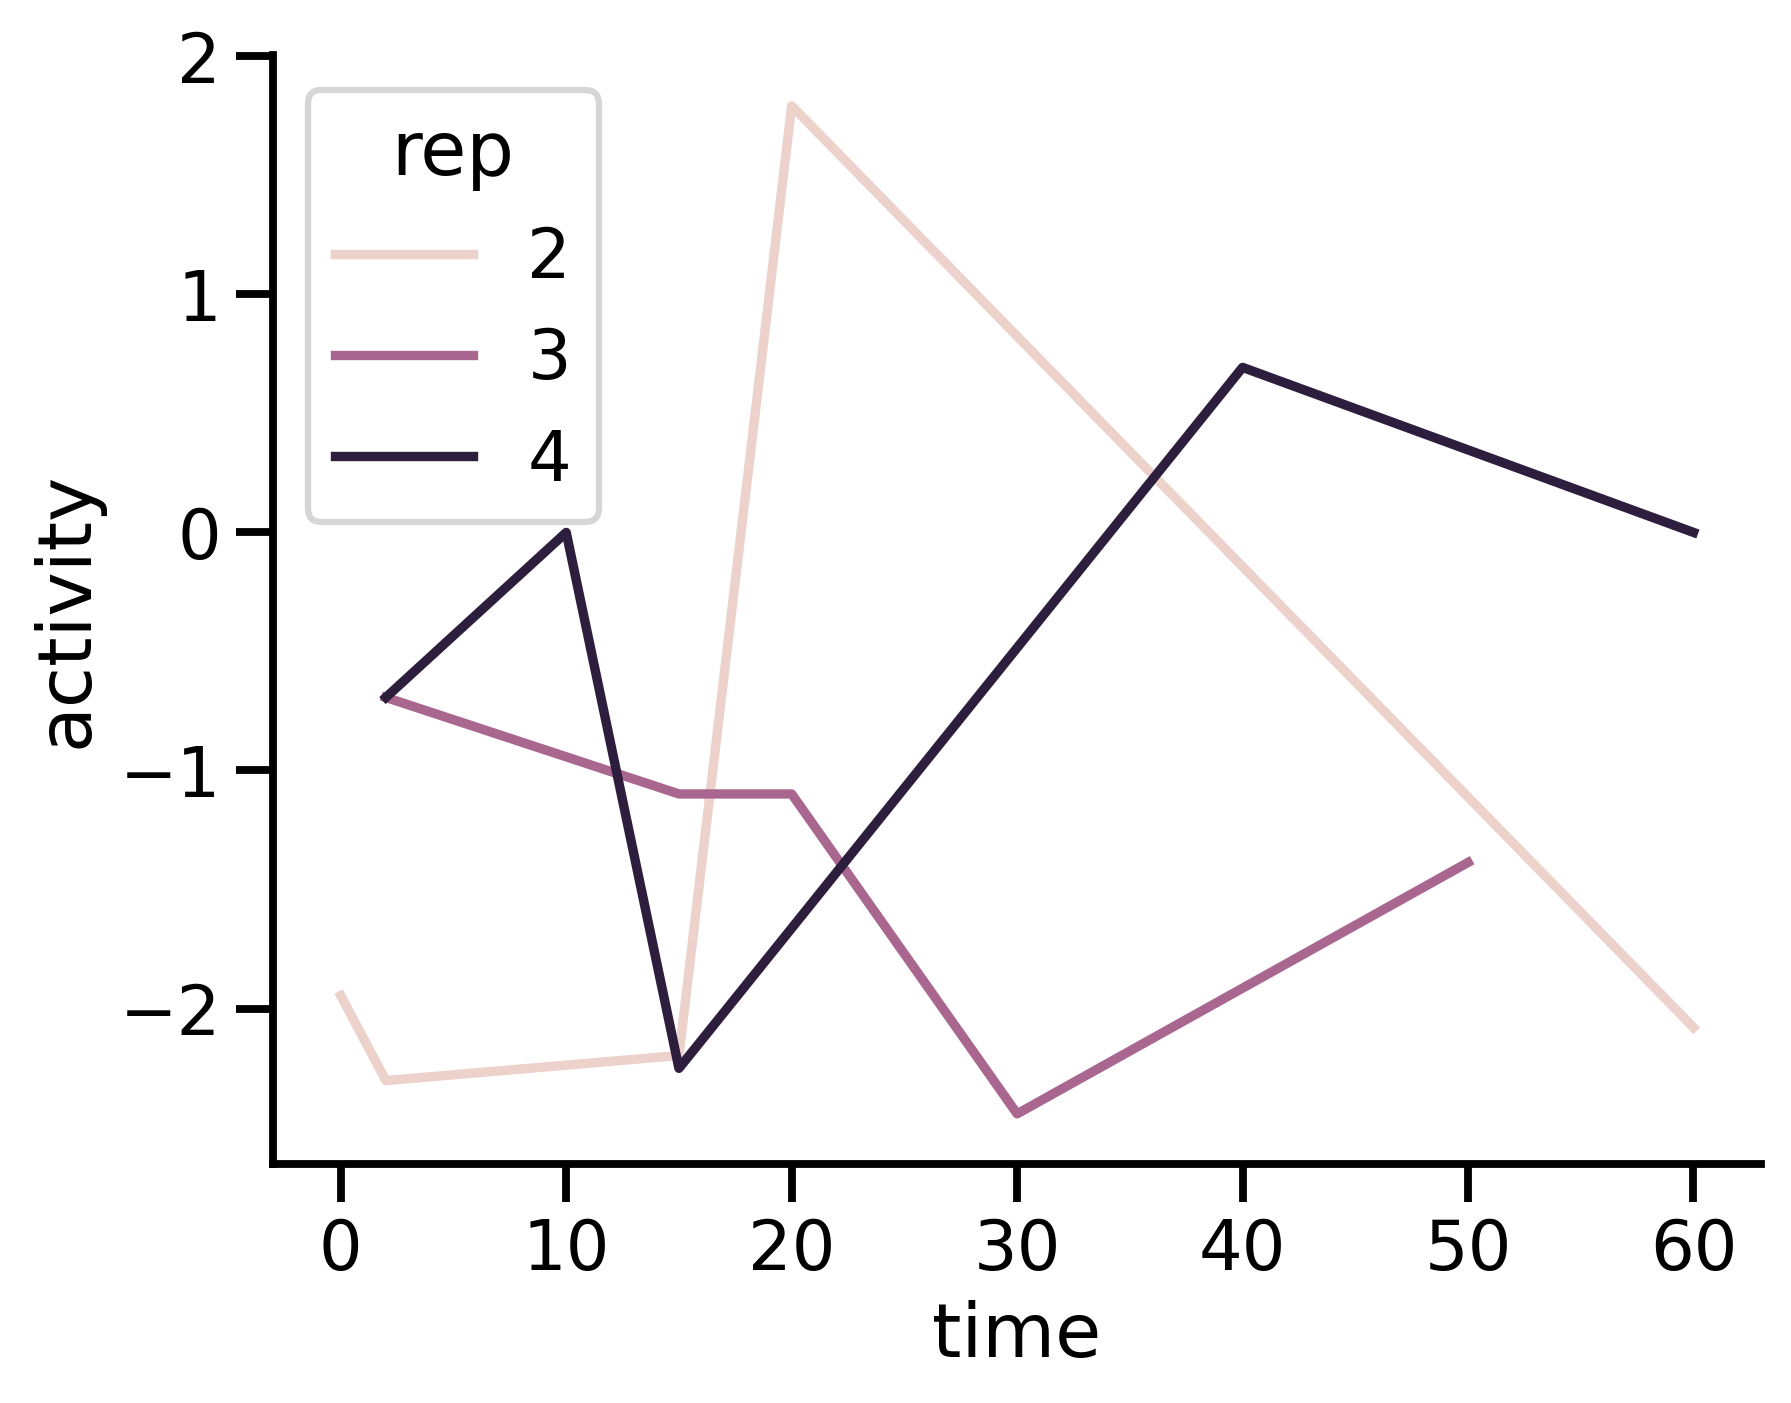

In [20]:
plt.figure(dpi = 300)
sns.lineplot(data = merged_result, x = "time", y = "activity", hue = "rep")
sns.despine()

# What if I dont look for flank in the AD end

In [21]:
mapped_AD = pd.merge(merged_AD_df, empty_AD_controls, on = "AD_BC")
mapped_AD

,AD_end,AD_BC,count_simple,file_base_simple,gene,rep,time,count_directional,file_base_directional,count_diff,AD_bases_end,RPTR_BC
0,TTTGGGTTTGCCATCTTTGGTTAATGCTAAAGATCACTTT,CCCCCCACCTC,1144,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TTTGGGTTTGCCATCTTTGGTTAATGCTAAAGATCACTTTCCCCCC...,4,50,1125,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,19,TCACTTT,AGACTTCCGGACCG
1,TGGCTATTCATATGTTGTCTTCTGAAGTTCAGAAATTGTC,CCCCCCACCTC,293,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGGCTATTCATATGTTGTCTTCTGAAGTTCAGAAATTGTCCCCCCC...,4,50,290,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,3,AATTGTC,AGACTTCCGGACCG
2,TACTATTGGTACTGCTATGTTTCAAGCTTTGAGAGTTGGT,CCCCCCACCTC,19,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TACTATTGGTACTGCTATGTTTCAAGCTTTGAGAGTTGGTCCCCCC...,4,50,19,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,0,AGTTGGT,AGACTTCCGGACCG
3,TGGCTATTCATATGTTGTCTTCTGAAGTGCAGAAATTGTC,CCCCCCACCTC,3,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGGCTATTCATATGTTGTCTTCTGAAGTGCAGAAATTGTCCCCCCC...,4,50,3,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,0,AATTGTC,AGACTTCCGGACCG
4,TTTGGGTTTGCCATCTTTGGTTAATGCGAAAGATCACTTT,CCCCCCACCTC,3,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TTTGGGTTTGCCATCTTTGGTTAATGCGAAAGATCACTTTCCCCCC...,4,50,3,AD_directional_AD_4_50_S29_R1_001_fastp_direct...,0,TCACTTT,AGACTTCCGGACCG
...,...,...,...,...,...,...,...,...,...,...,...,...
65545,TTCTTCATTTCAAGAACAACCATTGAATAAATTGTTGAAA,TAAACCCTTGC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TTCTTCATTTCAAGAACAACCATTGAATAAATTGTTGAAATAAACC...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0,GTTGAAA,TCCTTCGCAATTAT
65546,TGATTTGAAGACTTTGTTGGATAACTTTGGTAAGAAATTT,TTAATTTTCCC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TGATTTGAAGACTTTGTTGGATAACTTTGGTAAGAAATTTTTAATT...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0,GAAATTT,ATGACCTGAAAAAA
65547,TACAAGGGGGTTTCTTCTTCATGGTTCGCGGCGGCAACTG,TAAGTAAAGAA,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TACAAGGGGGTTTCTTCTTCATGGTTCGCGGCGGCAACTGTAAGTA...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0,GCAACTG,CTCGCATCCGACGT
65548,CGGGACTGTGAAATGGATTTCAAATGTTAAGGCTAATGTG,GAGAGTCAGAT,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,CGGGACTGTGAAATGGATTTCAAATGTTAAGGCTAATGTGGAGAGT...,3,60,1,AD_directional_AD_3_60_S20_R1_001_fastp_direct...,0,TAATGTG,ATTGTACTGAAGAG


In [22]:
mapped_AD = mapped_AD.drop(columns = ["AD_end", "gene"])
mapped_AD = mapped_AD[["AD_BC", "RPTR_BC", "rep", "time", "count_directional"]].groupby(["AD_BC", "RPTR_BC", "rep", "time"]).sum().reset_index()
mapped_AD

,AD_BC,RPTR_BC,rep,time,count_directional
0,AAAAAAAAGTG,GGATTCTTACCTGG,4,50,1
1,AAAAAAAAGTG,GGATTCTTACCTGG,4,60,1
2,AAAAAAATAGC,AAAGATACCTCTTT,4,5,1
3,AAAAAACACCC,ACAATGTATACTGA,2,0,1
4,AAAAAACACCC,ACAATGTATACTGA,4,0,1
...,...,...,...,...,...
25703,TTTTGTCGGAG,AATACTTACTTTGA,2,0,1
25704,TTTTTAGGATA,TCTTTTGGGTTGAC,2,15,1
25705,TTTTTGTCCGT,ATGCACGGAGTGAA,4,0,1
25706,TTTTTTGCAAG,CTGGTTCAGAGGGA,2,60,2


In [23]:
mapped_AD["AD_BC"].value_counts()

AD_BC
TCATCGACACA    90
ACTTCTGAATC    90
AGAGTAAAAAA    60
GTTATATAAAT    60
ACGAATCACAA    60
               ..
GTCGTTTTTAC     1
ATTTGTAAGTA     1
ATTTGGAAGTA     1
GTCTATCCTTA     1
CTAAGAGAACA     1
Name: count, Length: 2459, dtype: int64

In [24]:
merged_result_no_flank_search = pd.merge(mapped_AD, 
         mapped_RT[["AD_BC", "RPTR_BC", "count_directional", "rep", "time"]], 
         on = ["AD_BC", "RPTR_BC", "rep", "time"],
         suffixes = ("_AD", "_RT"))
merged_result_no_flank_search

,AD_BC,RPTR_BC,rep,time,count_directional_AD,count_directional_RT
0,AAAAAATAATA,GAATAAGGAAAAAG,2,0,34,1
1,AAAAAATAATA,GAATAAGGAAAAAG,2,15,33,1
2,AAAAAATAATA,GAATAAGGAAAAAG,2,20,44,6
3,AAAAAATAATA,GAATAAGGAAAAAG,2,30,51,2
4,AAAAAATAATA,GAATAAGGAAAAAG,2,40,29,7
...,...,...,...,...,...,...
12211,TTTTGGATCTT,ATAAGGGTGTCGCC,3,20,1,37
12212,TTTTGGATCTT,ATAAGGGTGTCGCC,3,50,1,22
12213,TTTTGGATCTT,ATAAGGGTGTCGCC,4,5,1,6
12214,TTTTTGTCCGT,ATGCACGGAGTGAA,4,0,1,1


In [25]:
merged_result_no_flank_search["activity"] = np.log(merged_result_no_flank_search["count_directional_RT"] / merged_result_no_flank_search["count_directional_AD"])
merged_result_no_flank_search

,AD_BC,RPTR_BC,rep,time,count_directional_AD,count_directional_RT,activity
0,AAAAAATAATA,GAATAAGGAAAAAG,2,0,34,1,-3.526361
1,AAAAAATAATA,GAATAAGGAAAAAG,2,15,33,1,-3.496508
2,AAAAAATAATA,GAATAAGGAAAAAG,2,20,44,6,-1.992430
3,AAAAAATAATA,GAATAAGGAAAAAG,2,30,51,2,-3.238678
4,AAAAAATAATA,GAATAAGGAAAAAG,2,40,29,7,-1.421386
...,...,...,...,...,...,...,...
12211,TTTTGGATCTT,ATAAGGGTGTCGCC,3,20,1,37,3.610918
12212,TTTTGGATCTT,ATAAGGGTGTCGCC,3,50,1,22,3.091042
12213,TTTTGGATCTT,ATAAGGGTGTCGCC,4,5,1,6,1.791759
12214,TTTTTGTCCGT,ATGCACGGAGTGAA,4,0,1,1,0.000000


In [26]:
merged_result_no_flank_search.to_csv("../../../output/ChopTFs_pipeline_step1_empty_ADs/empty_AD_trebl_results.csv")

In [27]:
merged_result_no_flank_search[["AD_BC", "RPTR_BC"]].value_counts()

AD_BC        RPTR_BC       
AGACTACCGTA  TAACAAAATAAGAC    30
AGCAGCCCTAA  CGATCGCGTGCCTA    30
ACTTTTGAATT  GAGAAATTACACTA    30
TAAAATCTACA  TTGGCGATTTGTAG    30
TAAAAGAATGG  TATAACGCGATTGT    30
                               ..
TCCAGCATGTT  CGGCTGACCCTTAG     1
GAACAGCCTCA  TACGATGCGTAGCA     1
GAAATACTAAG  CGAGACGACAACAC     1
GAAAGACCTGG  CCTAGGCGAAAGTG     1
TTTTTTGCAAG  CTGGTTCAGAGGGA     1
Name: count, Length: 809, dtype: int64

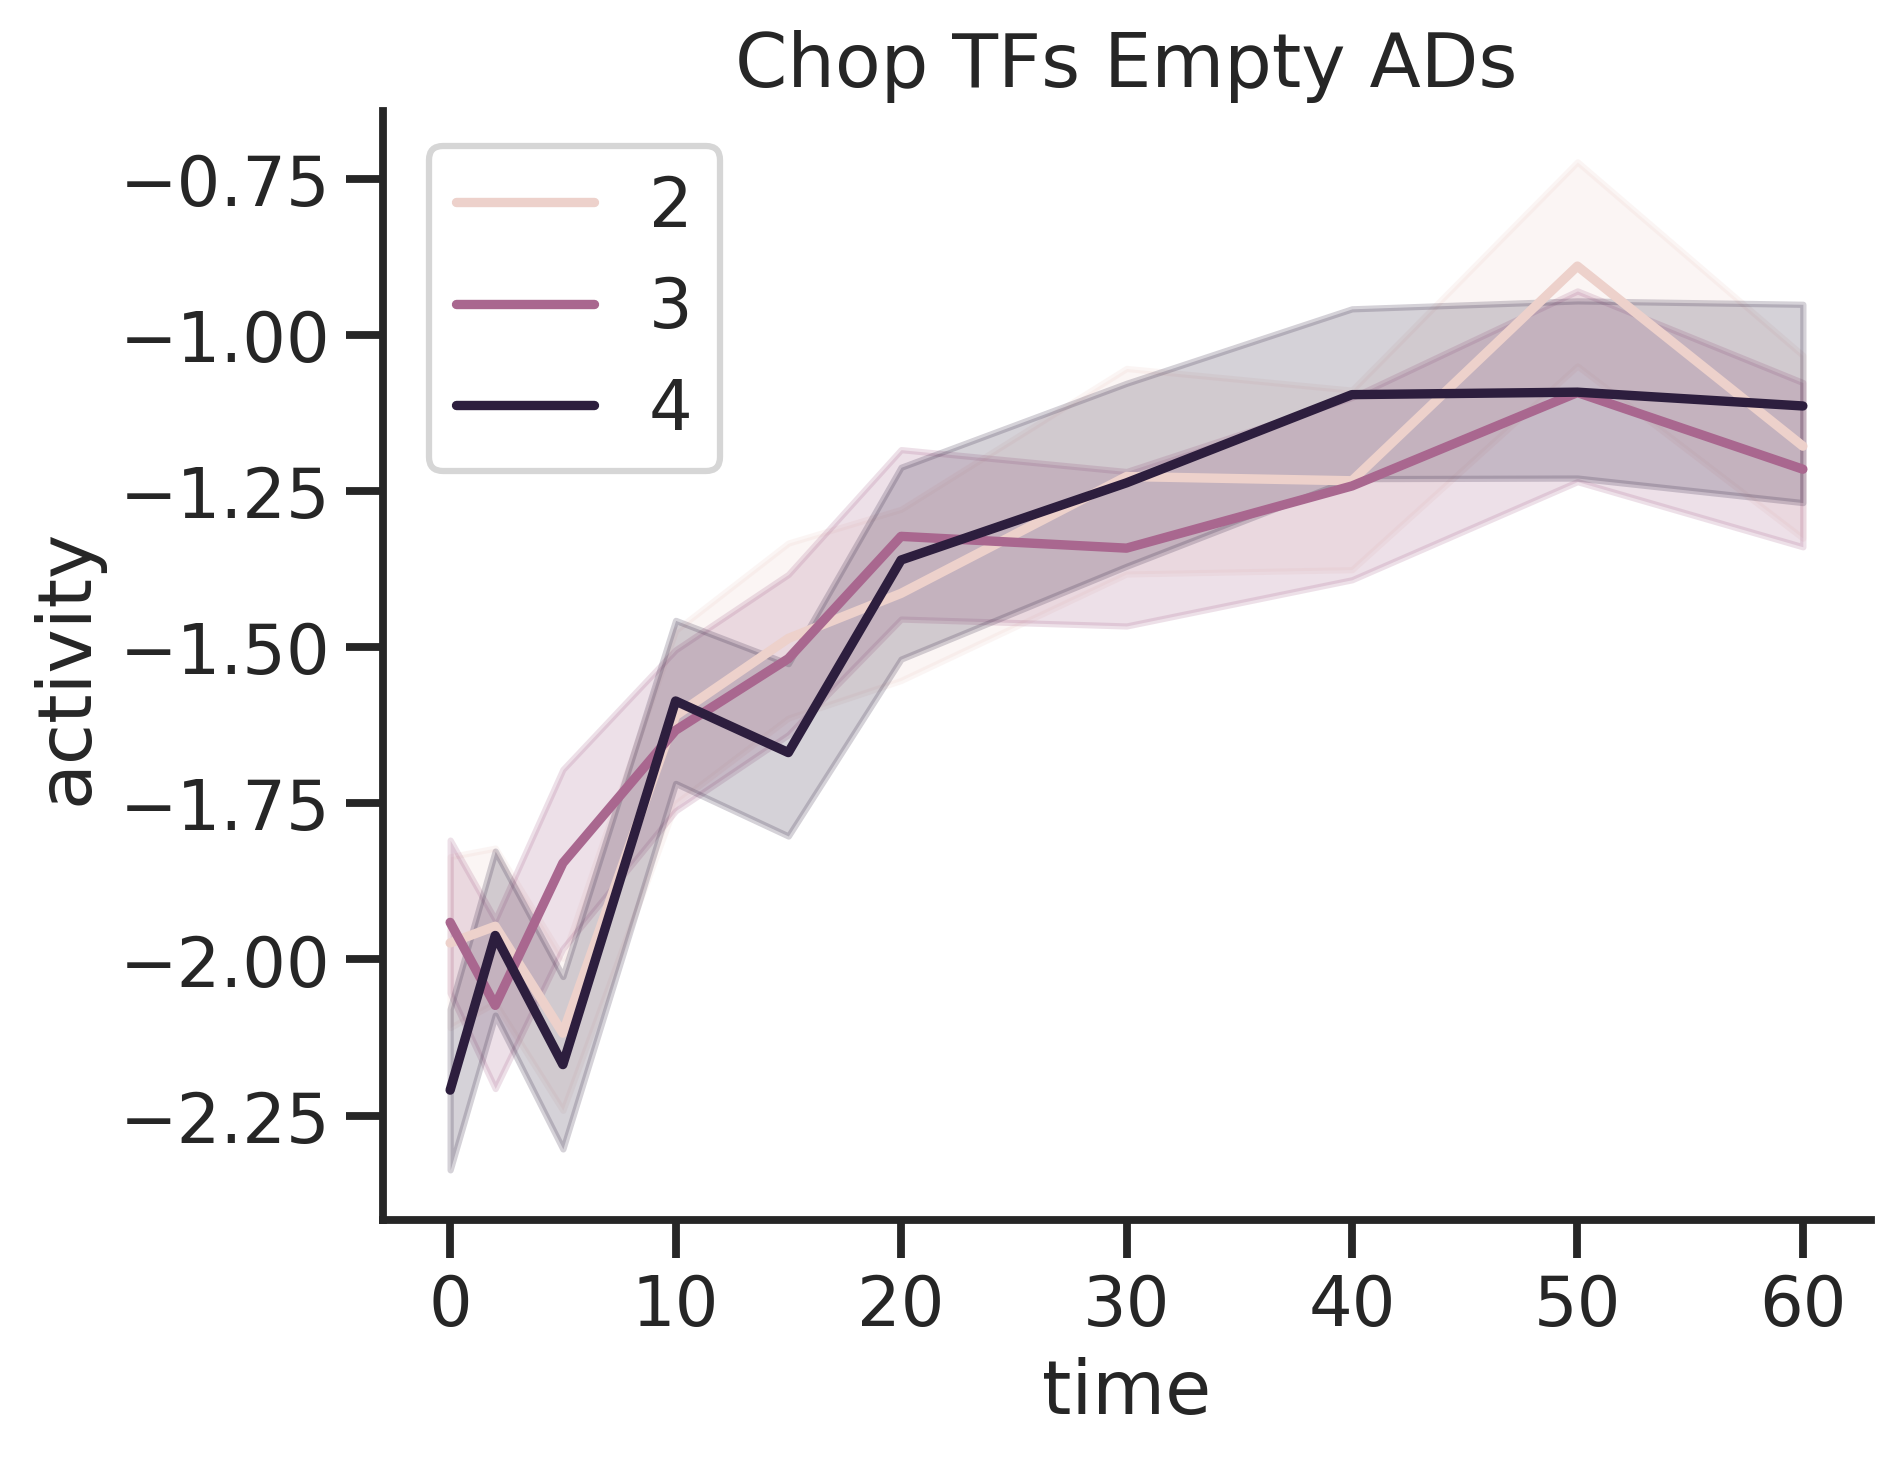

In [28]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(dpi = 300)
sns.lineplot(data = merged_result_no_flank_search, x = "time", y = "activity", hue = "rep")
plt.title("Chop TFs Empty ADs")
plt.legend(loc = 'upper right', bbox_to_anchor = (.25,1))
sns.despine()

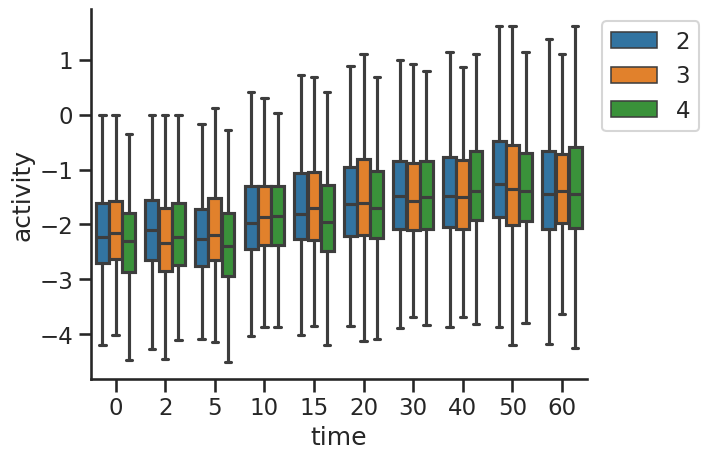

In [29]:
sns.boxplot(data = merged_result_no_flank_search, x = "time", y = "activity", hue = 'rep', showfliers = False)
plt.legend(loc = 'upper right', bbox_to_anchor = (1.25,1))
sns.despine()

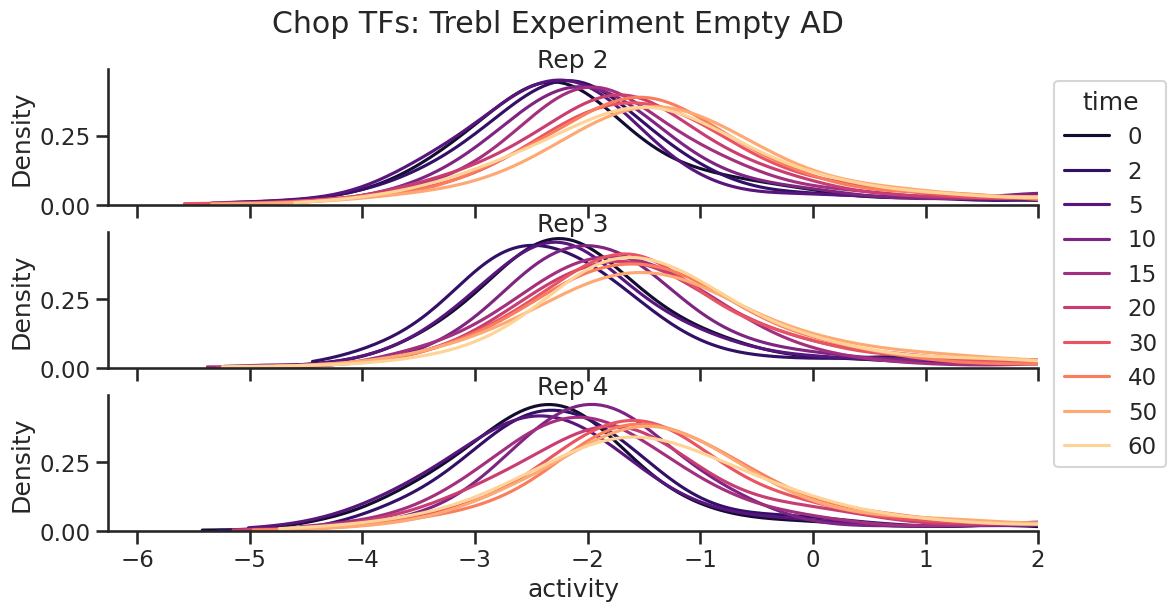

In [30]:
times = [0,2,5,10,15,20,30,40,50,60]
reps = [2,3,4]
sns.set_context('talk')
palette = sns.color_palette("magma", len(times))

fig, axes = plt.subplots(3,1, figsize=(12,6), sharex = True, sharey = True)

for ax, rep in zip(axes, reps):

    for i, time in enumerate(times):
        sns.kdeplot(
            merged_result_no_flank_search[
                (merged_result_no_flank_search["time"] == time) &
                (merged_result_no_flank_search["rep"] == rep)
            ]["activity"],
            cut=0,
            color=palette[i],
            ax=ax
        )

    ax.set_title(f"Rep {rep}", y = 0.95)
    sns.despine(ax=ax)
    plt.xlim(None,2)

axes[0].legend(title="time", labels=times, loc = 'upper right', bbox_to_anchor = (1.15,1))

plt.suptitle("Chop TFs: Trebl Experiment Empty AD")
plt.tight_layout(pad = 3)
plt.show()

Text(0.5, 0, 'AD UMIs')

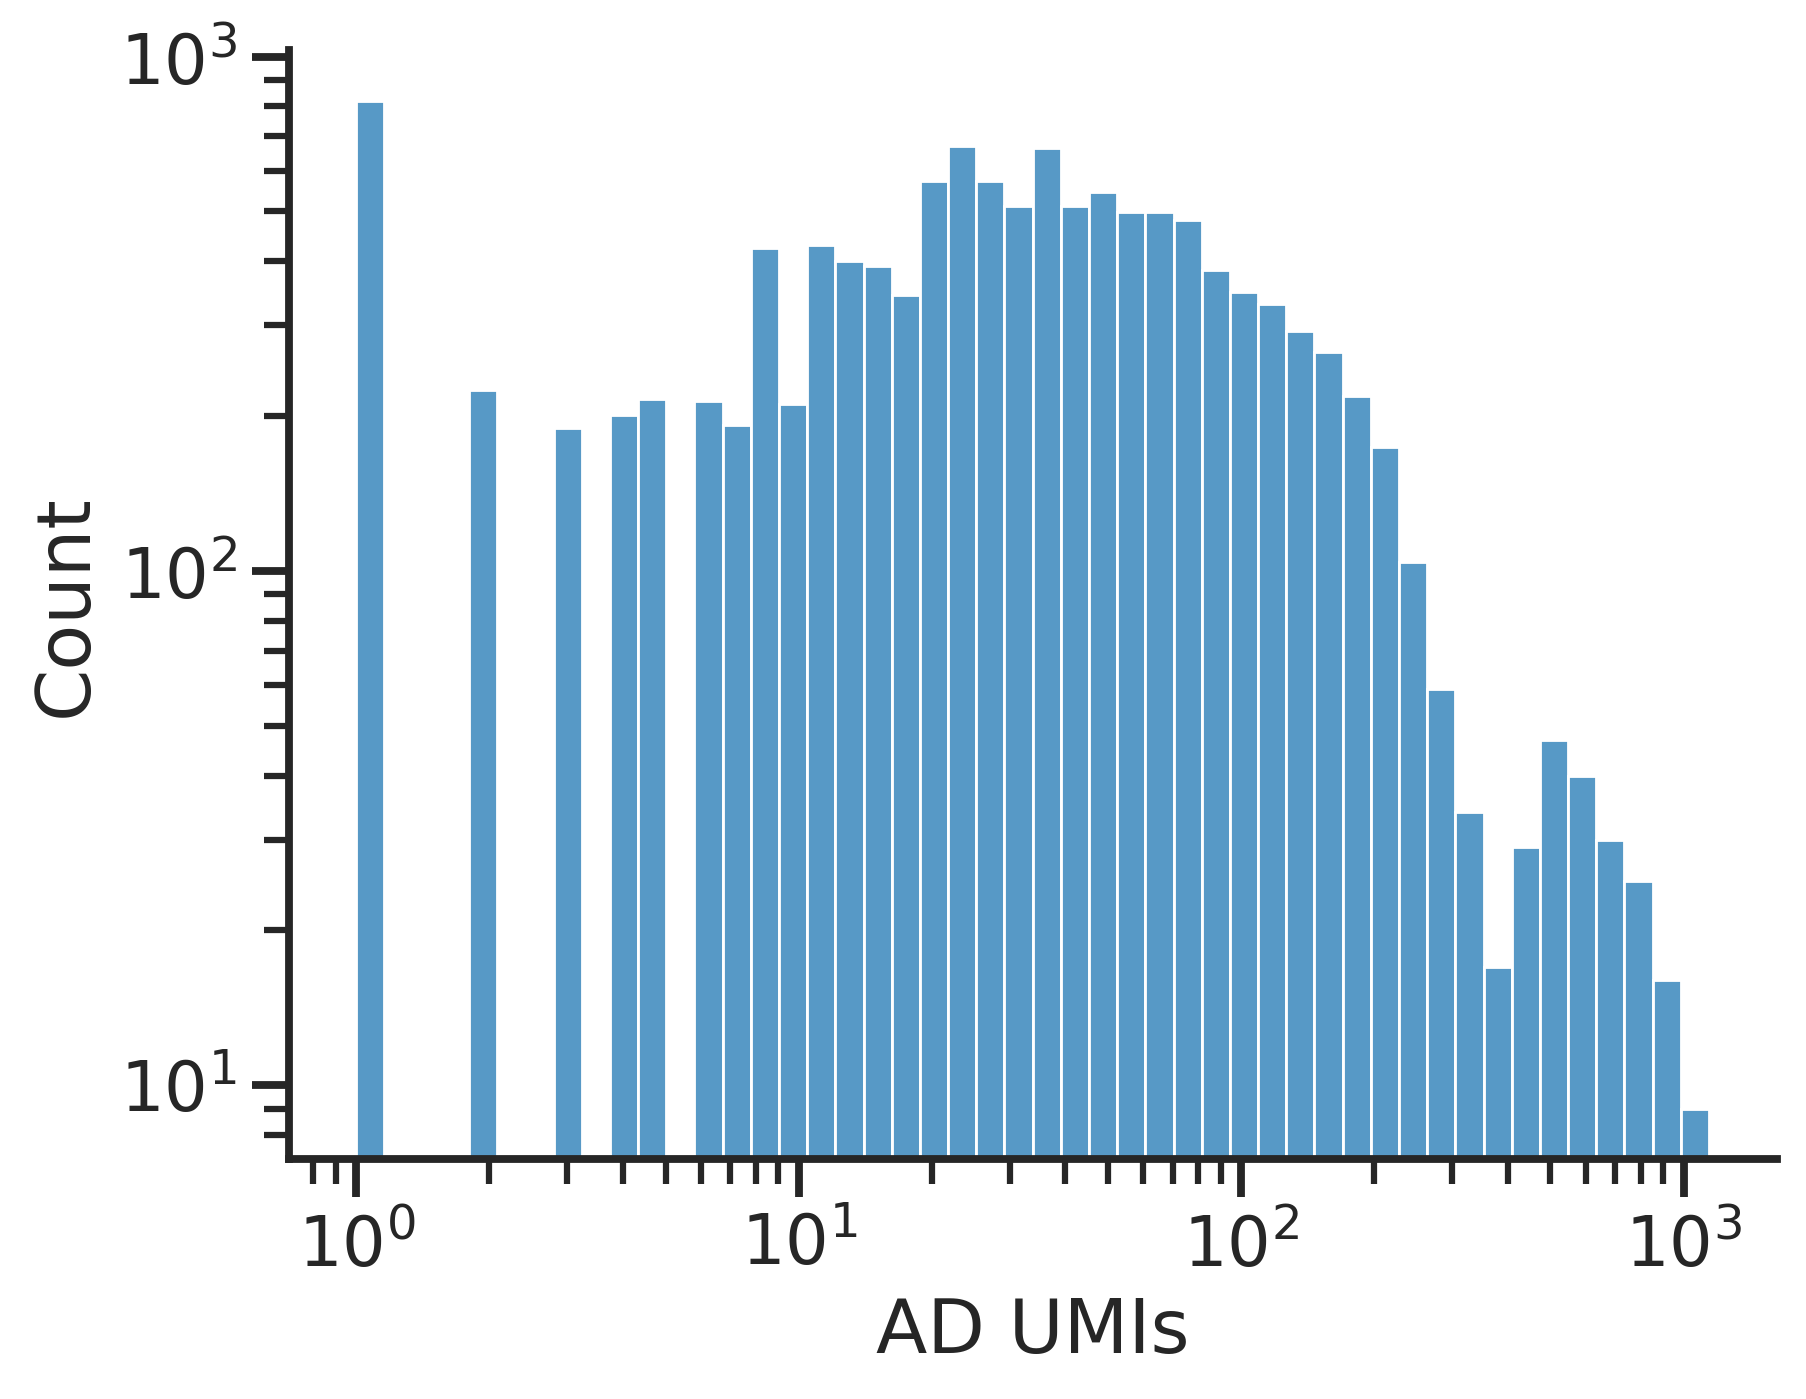

In [65]:
plt.figure(dpi = 300)
sns.histplot(merged_result_no_flank_search["count_directional_AD"], log_scale = (True, True))
sns.despine()
plt.xlabel("AD UMIs")

Text(0.5, 0, 'RT UMIs')

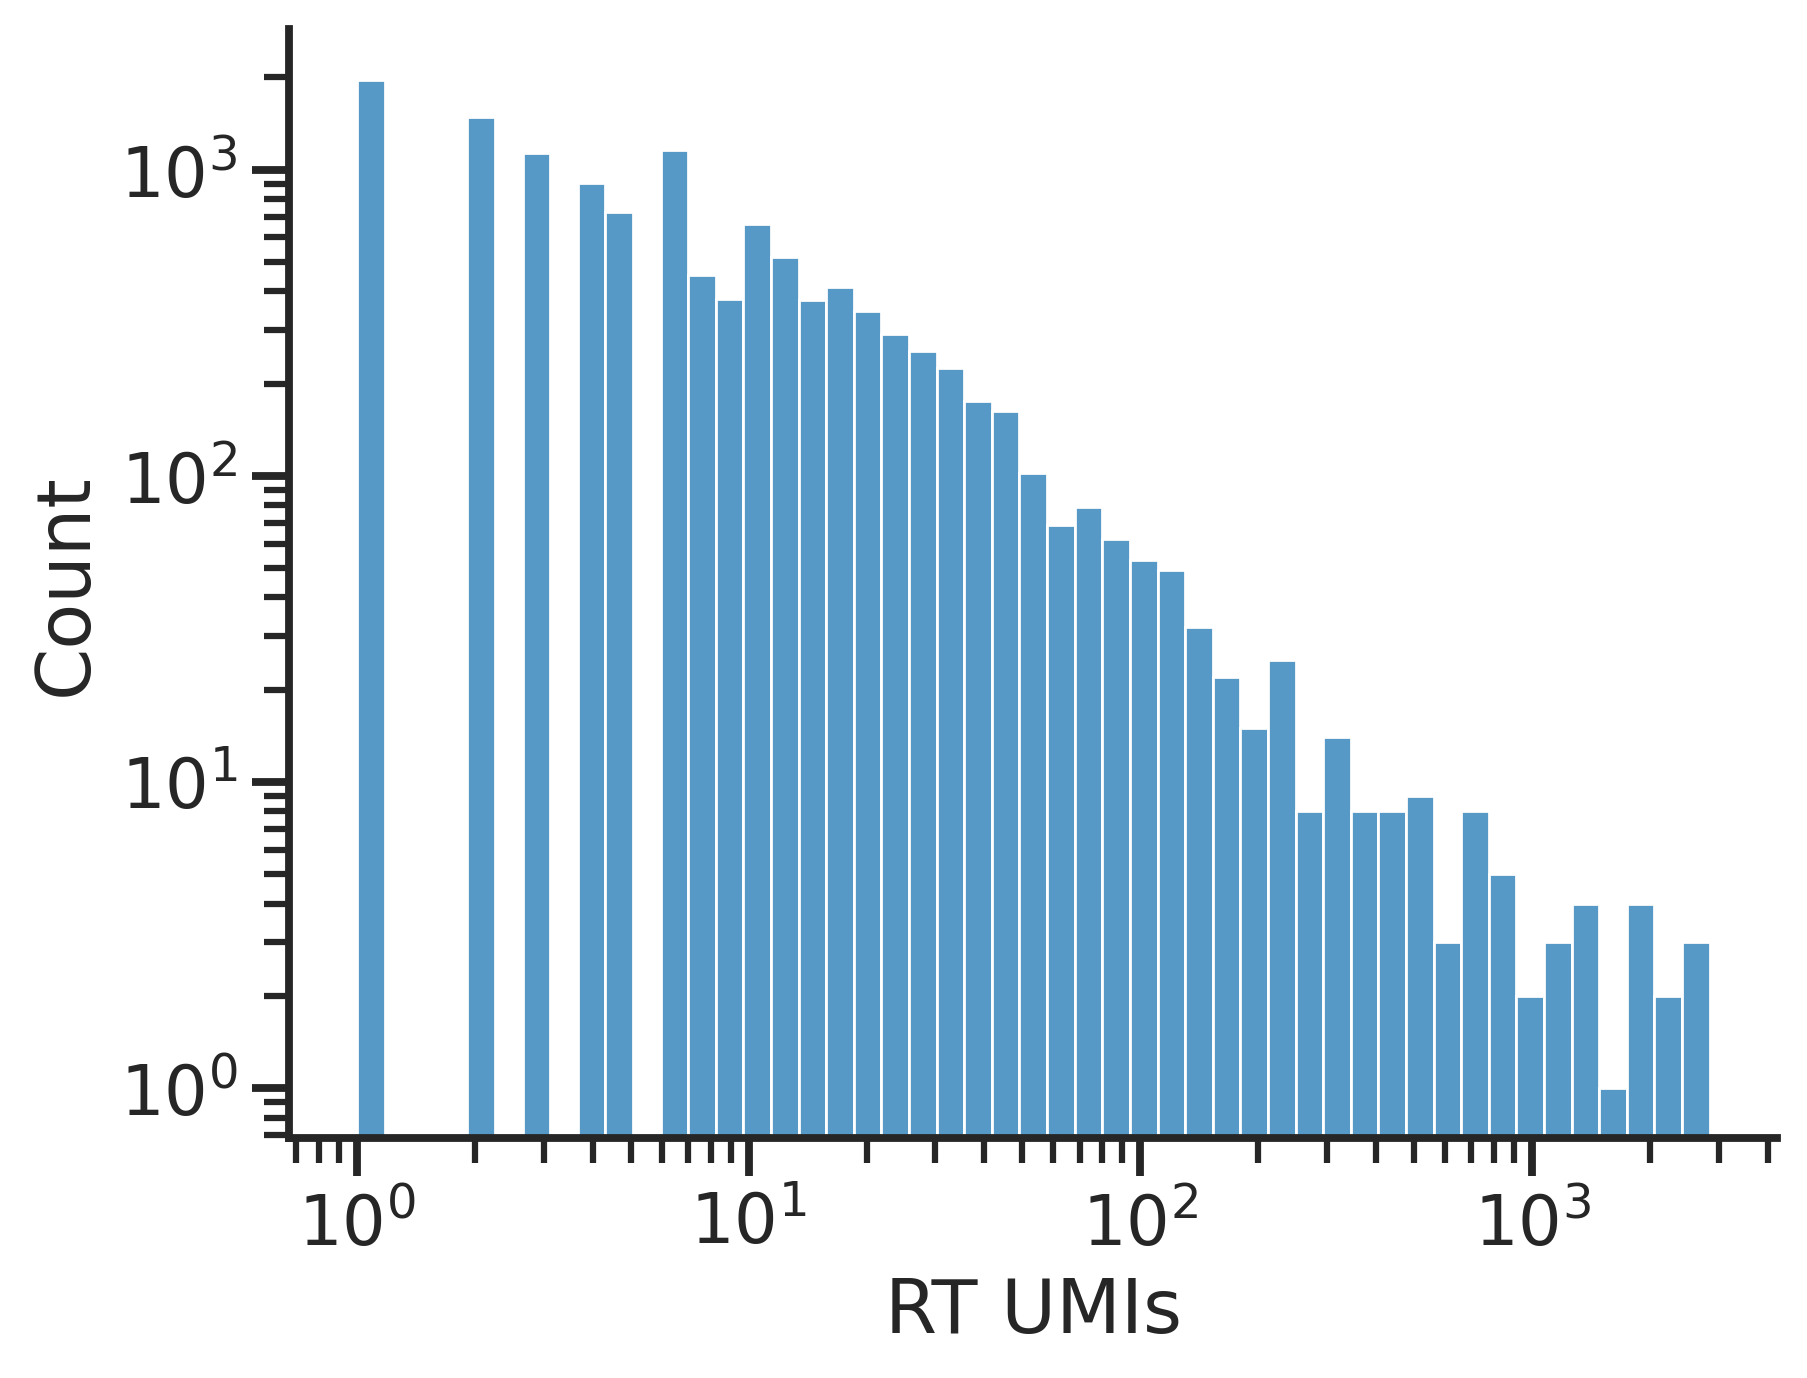

In [66]:
plt.figure(dpi = 300)
sns.histplot(merged_result_no_flank_search["count_directional_RT"], log_scale = (True, True))
sns.despine()
plt.xlabel("RT UMIs")

# plotting distirbutions

In [8]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/trebl_experiment_activities_per_barcode.csv", index_col = 0)
activities_rep2 = activities[activities["rep"] == 2]
activities_rep3 = activities[activities["rep"] == 3]
activities_rep4 = activities[activities["rep"] == 4]
activities

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [5]:
empty_AD_trebl_results = pd.read_csv("../../../output/ChopTFs_pipeline_step1_empty_ADs/empty_AD_trebl_results.csv")
empty_AD_trebl_results

,Unnamed: 0,AD_BC,RPTR_BC,rep,time,count_directional_AD,count_directional_RT,activity
0,0,AAAAAATAATA,GAATAAGGAAAAAG,2,0,34,1,-3.526361
1,1,AAAAAATAATA,GAATAAGGAAAAAG,2,15,33,1,-3.496508
2,2,AAAAAATAATA,GAATAAGGAAAAAG,2,20,44,6,-1.992430
3,3,AAAAAATAATA,GAATAAGGAAAAAG,2,30,51,2,-3.238678
4,4,AAAAAATAATA,GAATAAGGAAAAAG,2,40,29,7,-1.421386
...,...,...,...,...,...,...,...,...
12211,12211,TTTTGGATCTT,ATAAGGGTGTCGCC,3,20,1,37,3.610918
12212,12212,TTTTGGATCTT,ATAAGGGTGTCGCC,3,50,1,22,3.091042
12213,12213,TTTTGGATCTT,ATAAGGGTGTCGCC,4,5,1,6,1.791759
12214,12214,TTTTTGTCCGT,ATGCACGGAGTGAA,4,0,1,1,0.000000


100%|██████████| 10/10 [00:00<00:00, 11.92it/s]


Text(0.5, 0.9, 'Chop TFs Rep 2')

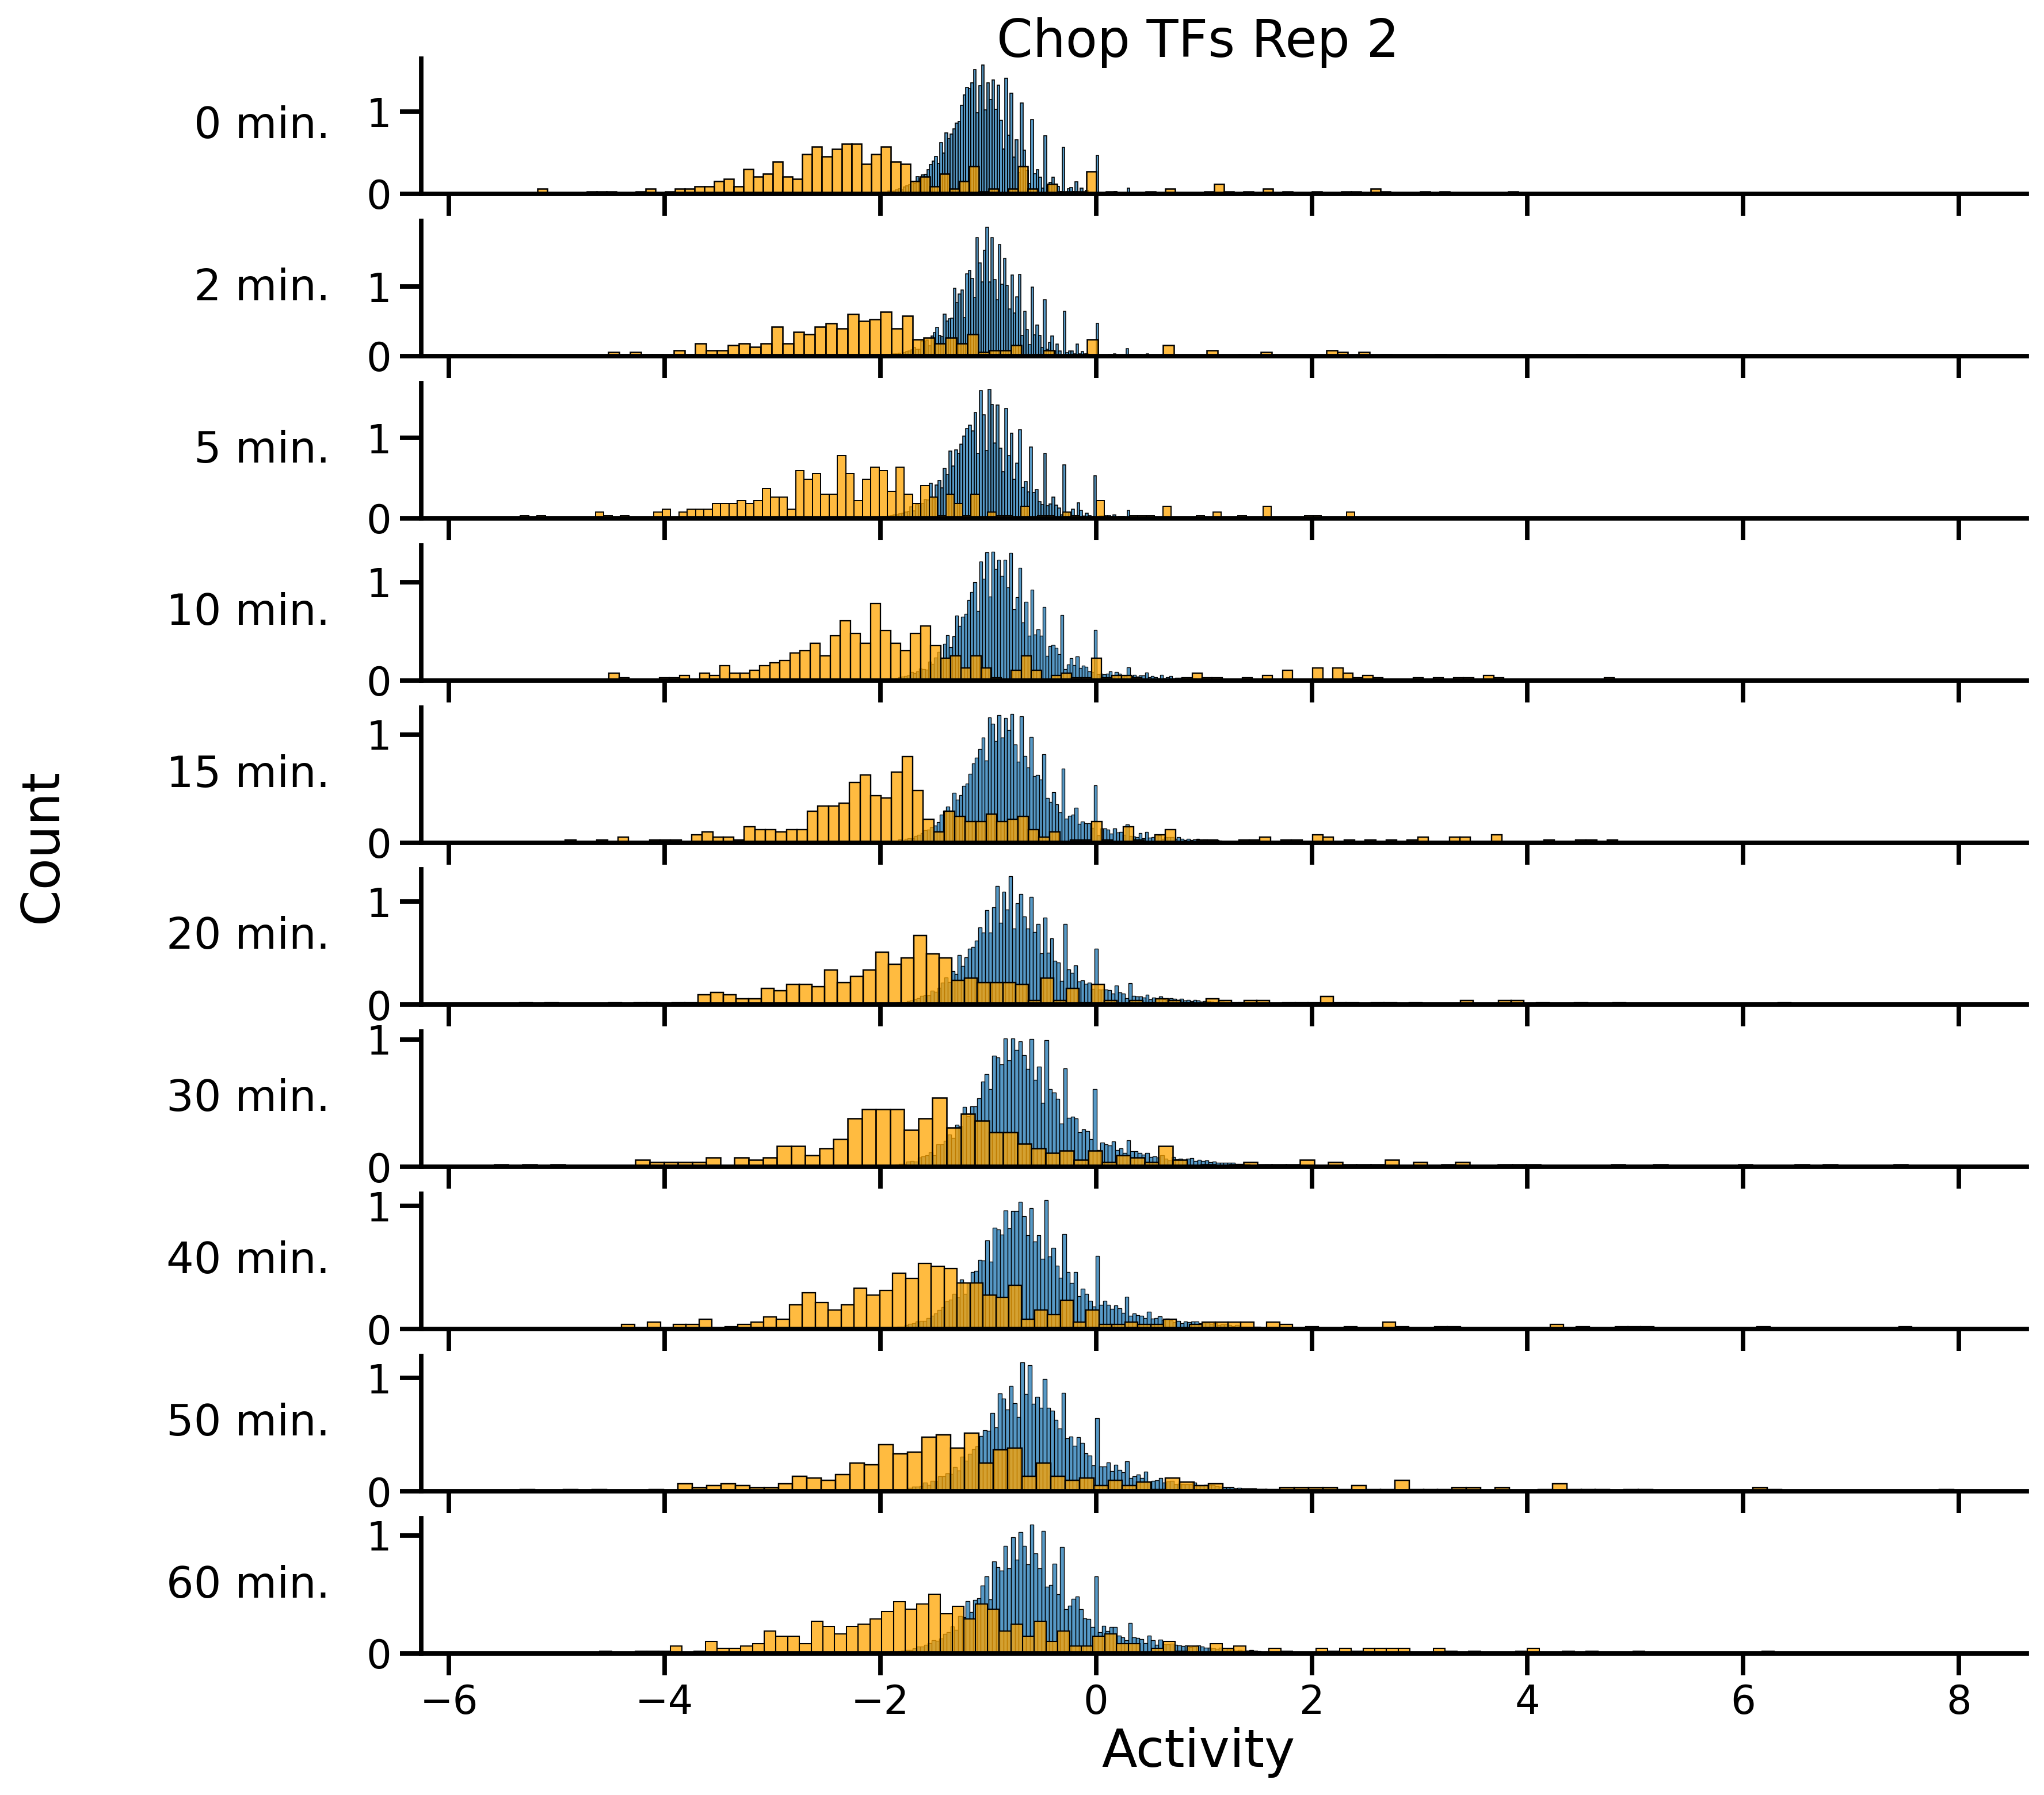

In [11]:
fig,axs = time_normalization_helpers.plot_hists_over_time(activities_rep2)

times = np.array(empty_AD_trebl_results["time"].drop_duplicates().sort_values())
    
for i in tqdm.tqdm(range(len(times))):
    sns.histplot(data = empty_AD_trebl_results[(empty_AD_trebl_results["rep"] == 2) & (empty_AD_trebl_results["time"] == times[i])], 
                 x = "activity", 
                 ax = axs[i],
                stat = 'density', color = 'orange', bins = 100, label = "Empty ADs")
    axs[i].set_xlabel("")
    
fig.suptitle("Chop TFs Rep 2", y = 0.9)

100%|██████████| 10/10 [00:01<00:00,  7.41it/s]


Text(0.5, 0.9, 'Chop TFs Rep 2')

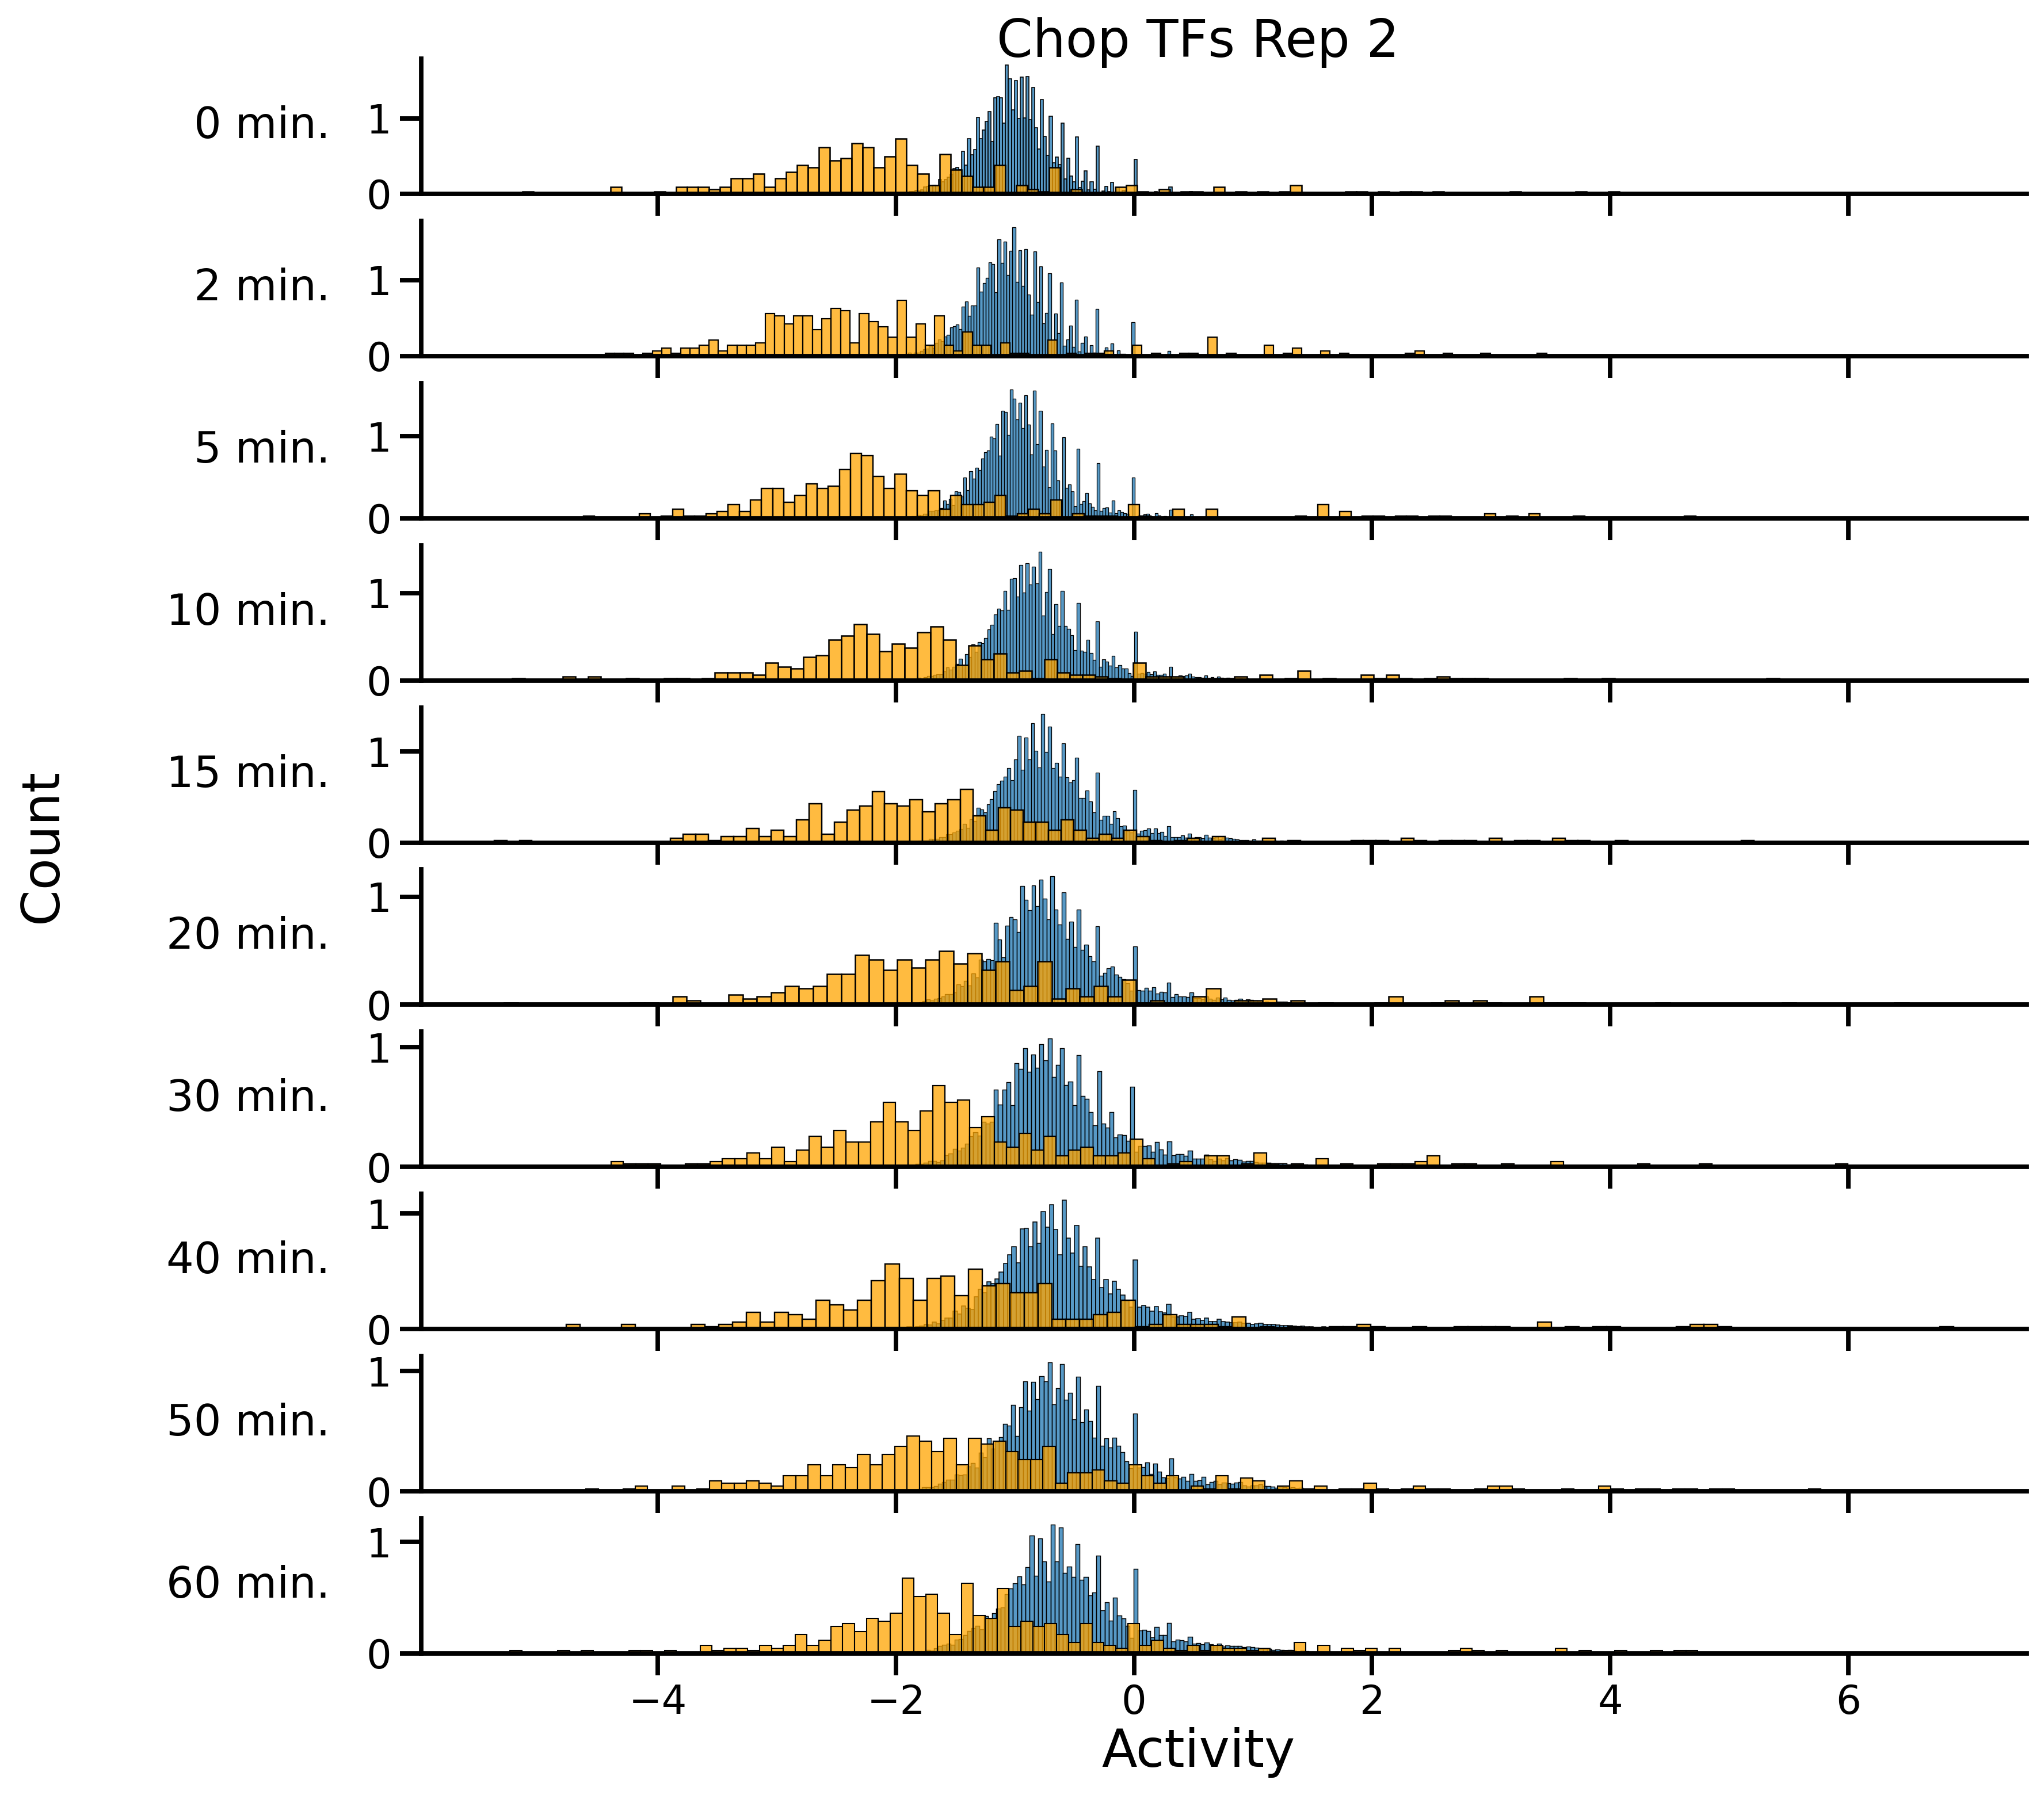

In [14]:
fig,axs = time_normalization_helpers.plot_hists_over_time(activities_rep3)

times = np.array(empty_AD_trebl_results["time"].drop_duplicates().sort_values())
    
for i in tqdm.tqdm(range(len(times))):
    sns.histplot(data = empty_AD_trebl_results[(empty_AD_trebl_results["rep"] == 3) & (empty_AD_trebl_results["time"] == times[i])], 
                 x = "activity", 
                 ax = axs[i],
                stat = 'density', color = 'orange', bins = 100, label = "Empty ADs")
    axs[i].set_xlabel("")
    
fig.suptitle("Chop TFs Rep 2", y = 0.9)

100%|██████████| 10/10 [00:00<00:00, 11.82it/s]


Text(0.5, 0.9, 'Chop TFs Rep 2')

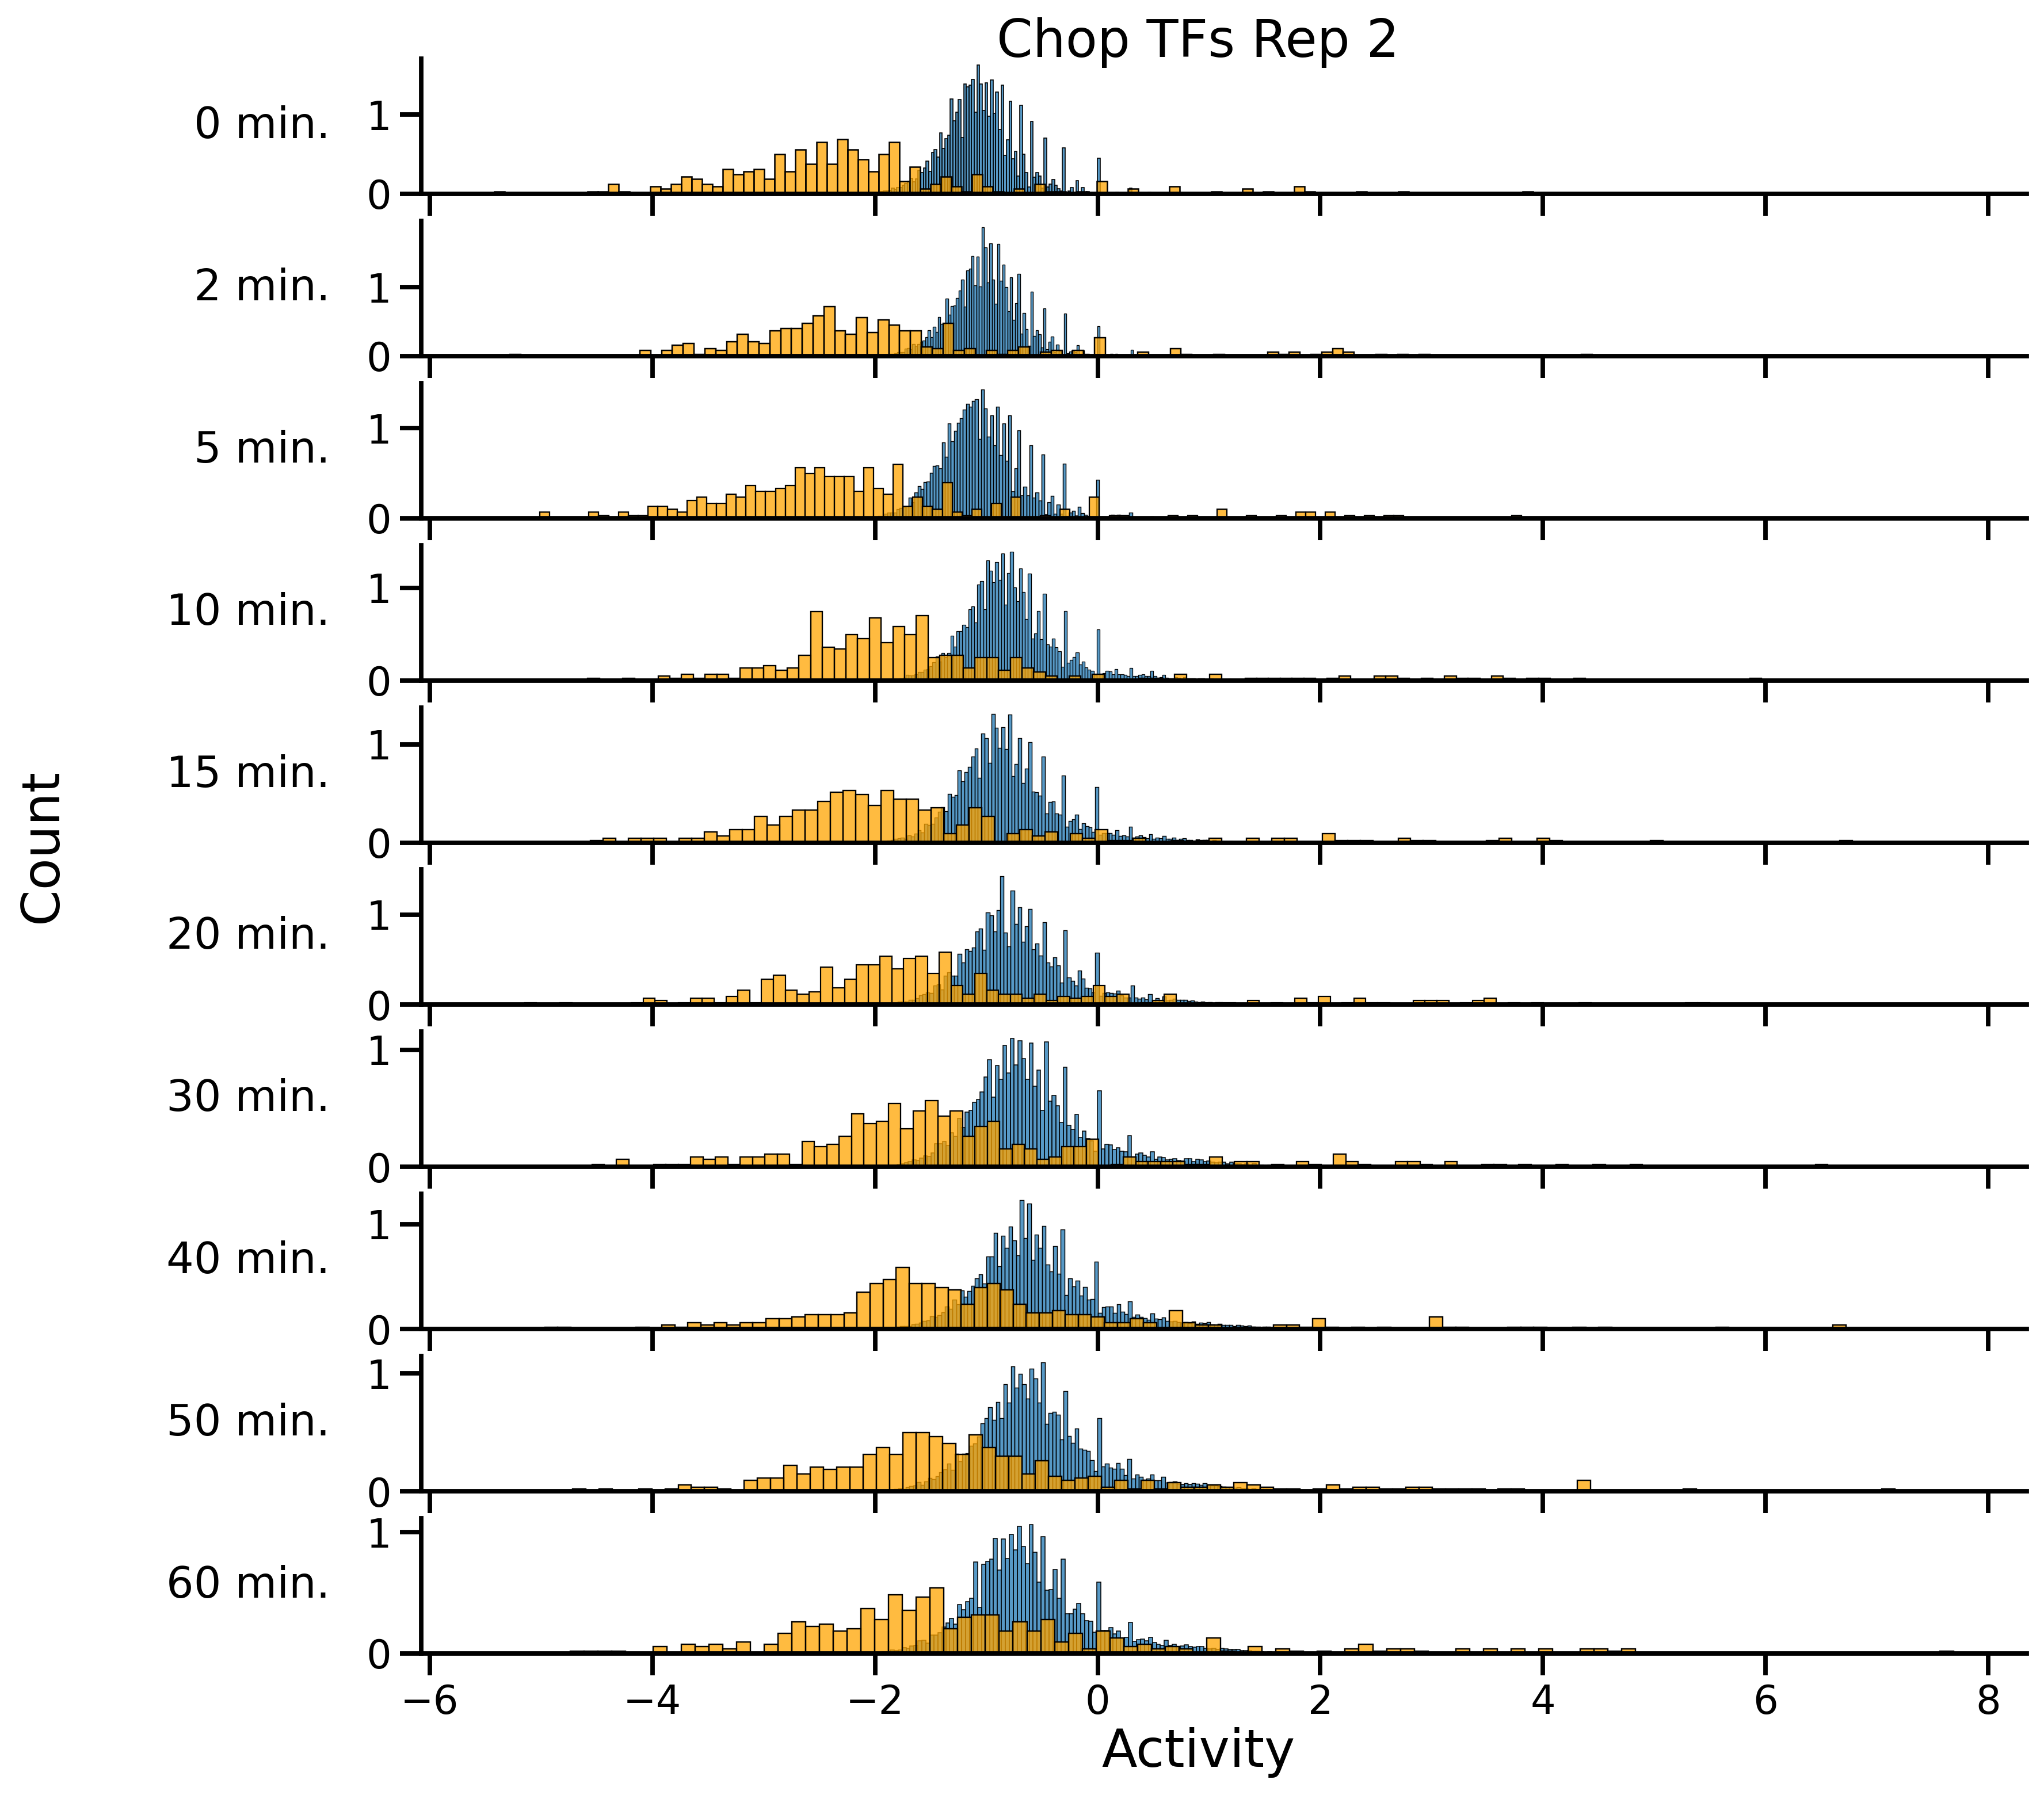

In [15]:
fig,axs = time_normalization_helpers.plot_hists_over_time(activities_rep4)

times = np.array(empty_AD_trebl_results["time"].drop_duplicates().sort_values())
    
for i in tqdm.tqdm(range(len(times))):
    sns.histplot(data = empty_AD_trebl_results[(empty_AD_trebl_results["rep"] == 4) & (empty_AD_trebl_results["time"] == times[i])], 
                 x = "activity", 
                 ax = axs[i],
                stat = 'density', color = 'orange', bins = 100, label = "Empty ADs")
    axs[i].set_xlabel("")
    
fig.suptitle("Chop TFs Rep 2", y = 0.9)

# Fitting normal distributions to no AD

In [31]:
merged_result_no_flank_search

,AD_BC,RPTR_BC,rep,time,count_directional_AD,count_directional_RT,activity
0,AAAAAATAATA,GAATAAGGAAAAAG,2,0,34,1,-3.526361
1,AAAAAATAATA,GAATAAGGAAAAAG,2,15,33,1,-3.496508
2,AAAAAATAATA,GAATAAGGAAAAAG,2,20,44,6,-1.992430
3,AAAAAATAATA,GAATAAGGAAAAAG,2,30,51,2,-3.238678
4,AAAAAATAATA,GAATAAGGAAAAAG,2,40,29,7,-1.421386
...,...,...,...,...,...,...,...
12211,TTTTGGATCTT,ATAAGGGTGTCGCC,3,20,1,37,3.610918
12212,TTTTGGATCTT,ATAAGGGTGTCGCC,3,50,1,22,3.091042
12213,TTTTGGATCTT,ATAAGGGTGTCGCC,4,5,1,6,1.791759
12214,TTTTTGTCCGT,ATGCACGGAGTGAA,4,0,1,1,0.000000


In [32]:
activities = merged_result_no_flank_search.rename(columns = {"activity" : "score"})
activities["seq"] = ""
activities

,AD_BC,RPTR_BC,rep,time,count_directional_AD,count_directional_RT,score,seq
0,AAAAAATAATA,GAATAAGGAAAAAG,2,0,34,1,-3.526361,
1,AAAAAATAATA,GAATAAGGAAAAAG,2,15,33,1,-3.496508,
2,AAAAAATAATA,GAATAAGGAAAAAG,2,20,44,6,-1.992430,
3,AAAAAATAATA,GAATAAGGAAAAAG,2,30,51,2,-3.238678,
4,AAAAAATAATA,GAATAAGGAAAAAG,2,40,29,7,-1.421386,
...,...,...,...,...,...,...,...,...
12211,TTTTGGATCTT,ATAAGGGTGTCGCC,3,20,1,37,3.610918,
12212,TTTTGGATCTT,ATAAGGGTGTCGCC,3,50,1,22,3.091042,
12213,TTTTGGATCTT,ATAAGGGTGTCGCC,4,5,1,6,1.791759,
12214,TTTTTGTCCGT,ATGCACGGAGTGAA,4,0,1,1,0.000000,


In [33]:
# Create a dictionary to hold the split dataframes
activities_by_time_rep = {}

# Group by 'time' and 'rep'
for (rep, time), group in activities.groupby(['rep', 'time']):
    activities_by_time_rep[(rep, time)] = group.reset_index(drop=True)

In [43]:
def fit_inactive_gaussian_v2(df, ax=None):
    scores = np.array(df["score"])
    search_ceiling = np.percentile(scores, 99)
    truncated = scores[scores < search_ceiling]
    
    # search_floor = np.percentile(scores, 0)
    # truncated = truncated[search_floor < truncated]

    kde = gaussian_kde(truncated, bw_method=0.2)
    x_vals = np.linspace(min(scores), search_ceiling, 1000)
    peak_location = x_vals[np.argmax(kde(x_vals))]
    left_of_peak = scores[scores < peak_location]
    mirrored = np.concatenate([left_of_peak, 2 * peak_location - left_of_peak])
    sigma = np.std(mirrored)
    mu = peak_location

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3), dpi=150)

    sns.histplot(truncated, ax=ax, stat='density', kde=True)
    ax.axvline(mu, color='red', linestyle='dashed', lw=2, label=f'peak={mu:.3f}')
    x = np.linspace(min(truncated), max(truncated), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)
    y_max = max(p.get_height() for p in ax.patches)
    # ax.set_ylim(0, y_max * 1.15)
    ax.legend(fontsize=8)
    ax.set_title(f"rep={df['rep'].iloc[0]}, time={df['time'].iloc[0]}", fontsize=8)

    df = df.copy()
    df["z-score"] = (df["score"] - mu) / sigma
    return df

,AD_BC,RPTR_BC,rep,time,count_directional_AD,count_directional_RT,score,seq,z-score
0,AAAACAAACCC,AGAATTAAATAAAA,2,5,127,5,-3.234749,,-1.115745
1,AAAACCGTTAC,TTCCATGATAGCAG,2,5,27,1,-3.295837,,-1.184799
2,AAAAGAACGAC,TTGGTATTTAATCA,2,5,47,8,-1.770706,,0.539243
3,AAAATATACGT,ACCTATATATTACC,2,5,3,5,0.510826,,3.118338
4,AAAGTTATCGA,ACCTTAATTTCAGA,2,5,91,6,-2.719100,,-0.532843
...,...,...,...,...,...,...,...,...,...
342,TTTACTAATTT,TTCCCCACGGGCAT,2,5,95,3,-3.455265,,-1.365020
343,TTTAGCAAAAA,CGTTTATACGATGA,2,5,36,1,-3.583519,,-1.510002
344,TTTATAGCCAT,TCTAGCGTGGAGAA,2,5,19,1,-2.944439,,-0.787571
345,TTTGTATAGTT,GCTATACCATAATG,2,5,33,3,-2.397895,,-0.169746


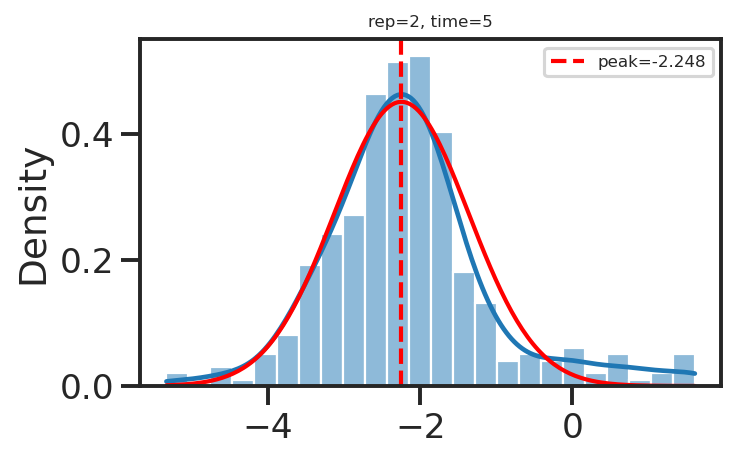

In [44]:
fit_inactive_gaussian_v2(activities_by_time_rep[(2,5)])

In [47]:
# --- Run once, cache results ---
groups = list(activities.groupby(['rep', 'time']))
cached_fits = {}  # (rep, time) -> (mu, sigma, truncated, df_out)

for (rep, time), group in tqdm.tqdm(groups):
    df = activities_by_time_rep[(rep, time)].copy()
    scores = np.array(df["score"])
    search_ceiling = np.percentile(scores, 97)
    truncated = scores[scores < search_ceiling]
    
    # search_floor = np.percentile(scores, 0)
    # truncated = truncated[search_floor < truncated]
    
    kde = gaussian_kde(truncated, bw_method=0.2)
    x_vals = np.linspace(min(scores), search_ceiling, 1000)
    peak_location = x_vals[np.argmax(kde(x_vals))]
    left_of_peak = scores[scores < peak_location]
    mirrored = np.concatenate([left_of_peak, 2 * peak_location - left_of_peak])
    sigma = np.std(mirrored)
    mu = peak_location
    df["z-score"] = (df["score"] - mu) / sigma
    cached_fits[(rep, time)] = (mu, sigma, truncated, df)

log_norm_activities = [cached_fits[k][3] for k in cached_fits]

100%|██████████| 30/30 [00:00<00:00, 94.29it/s]


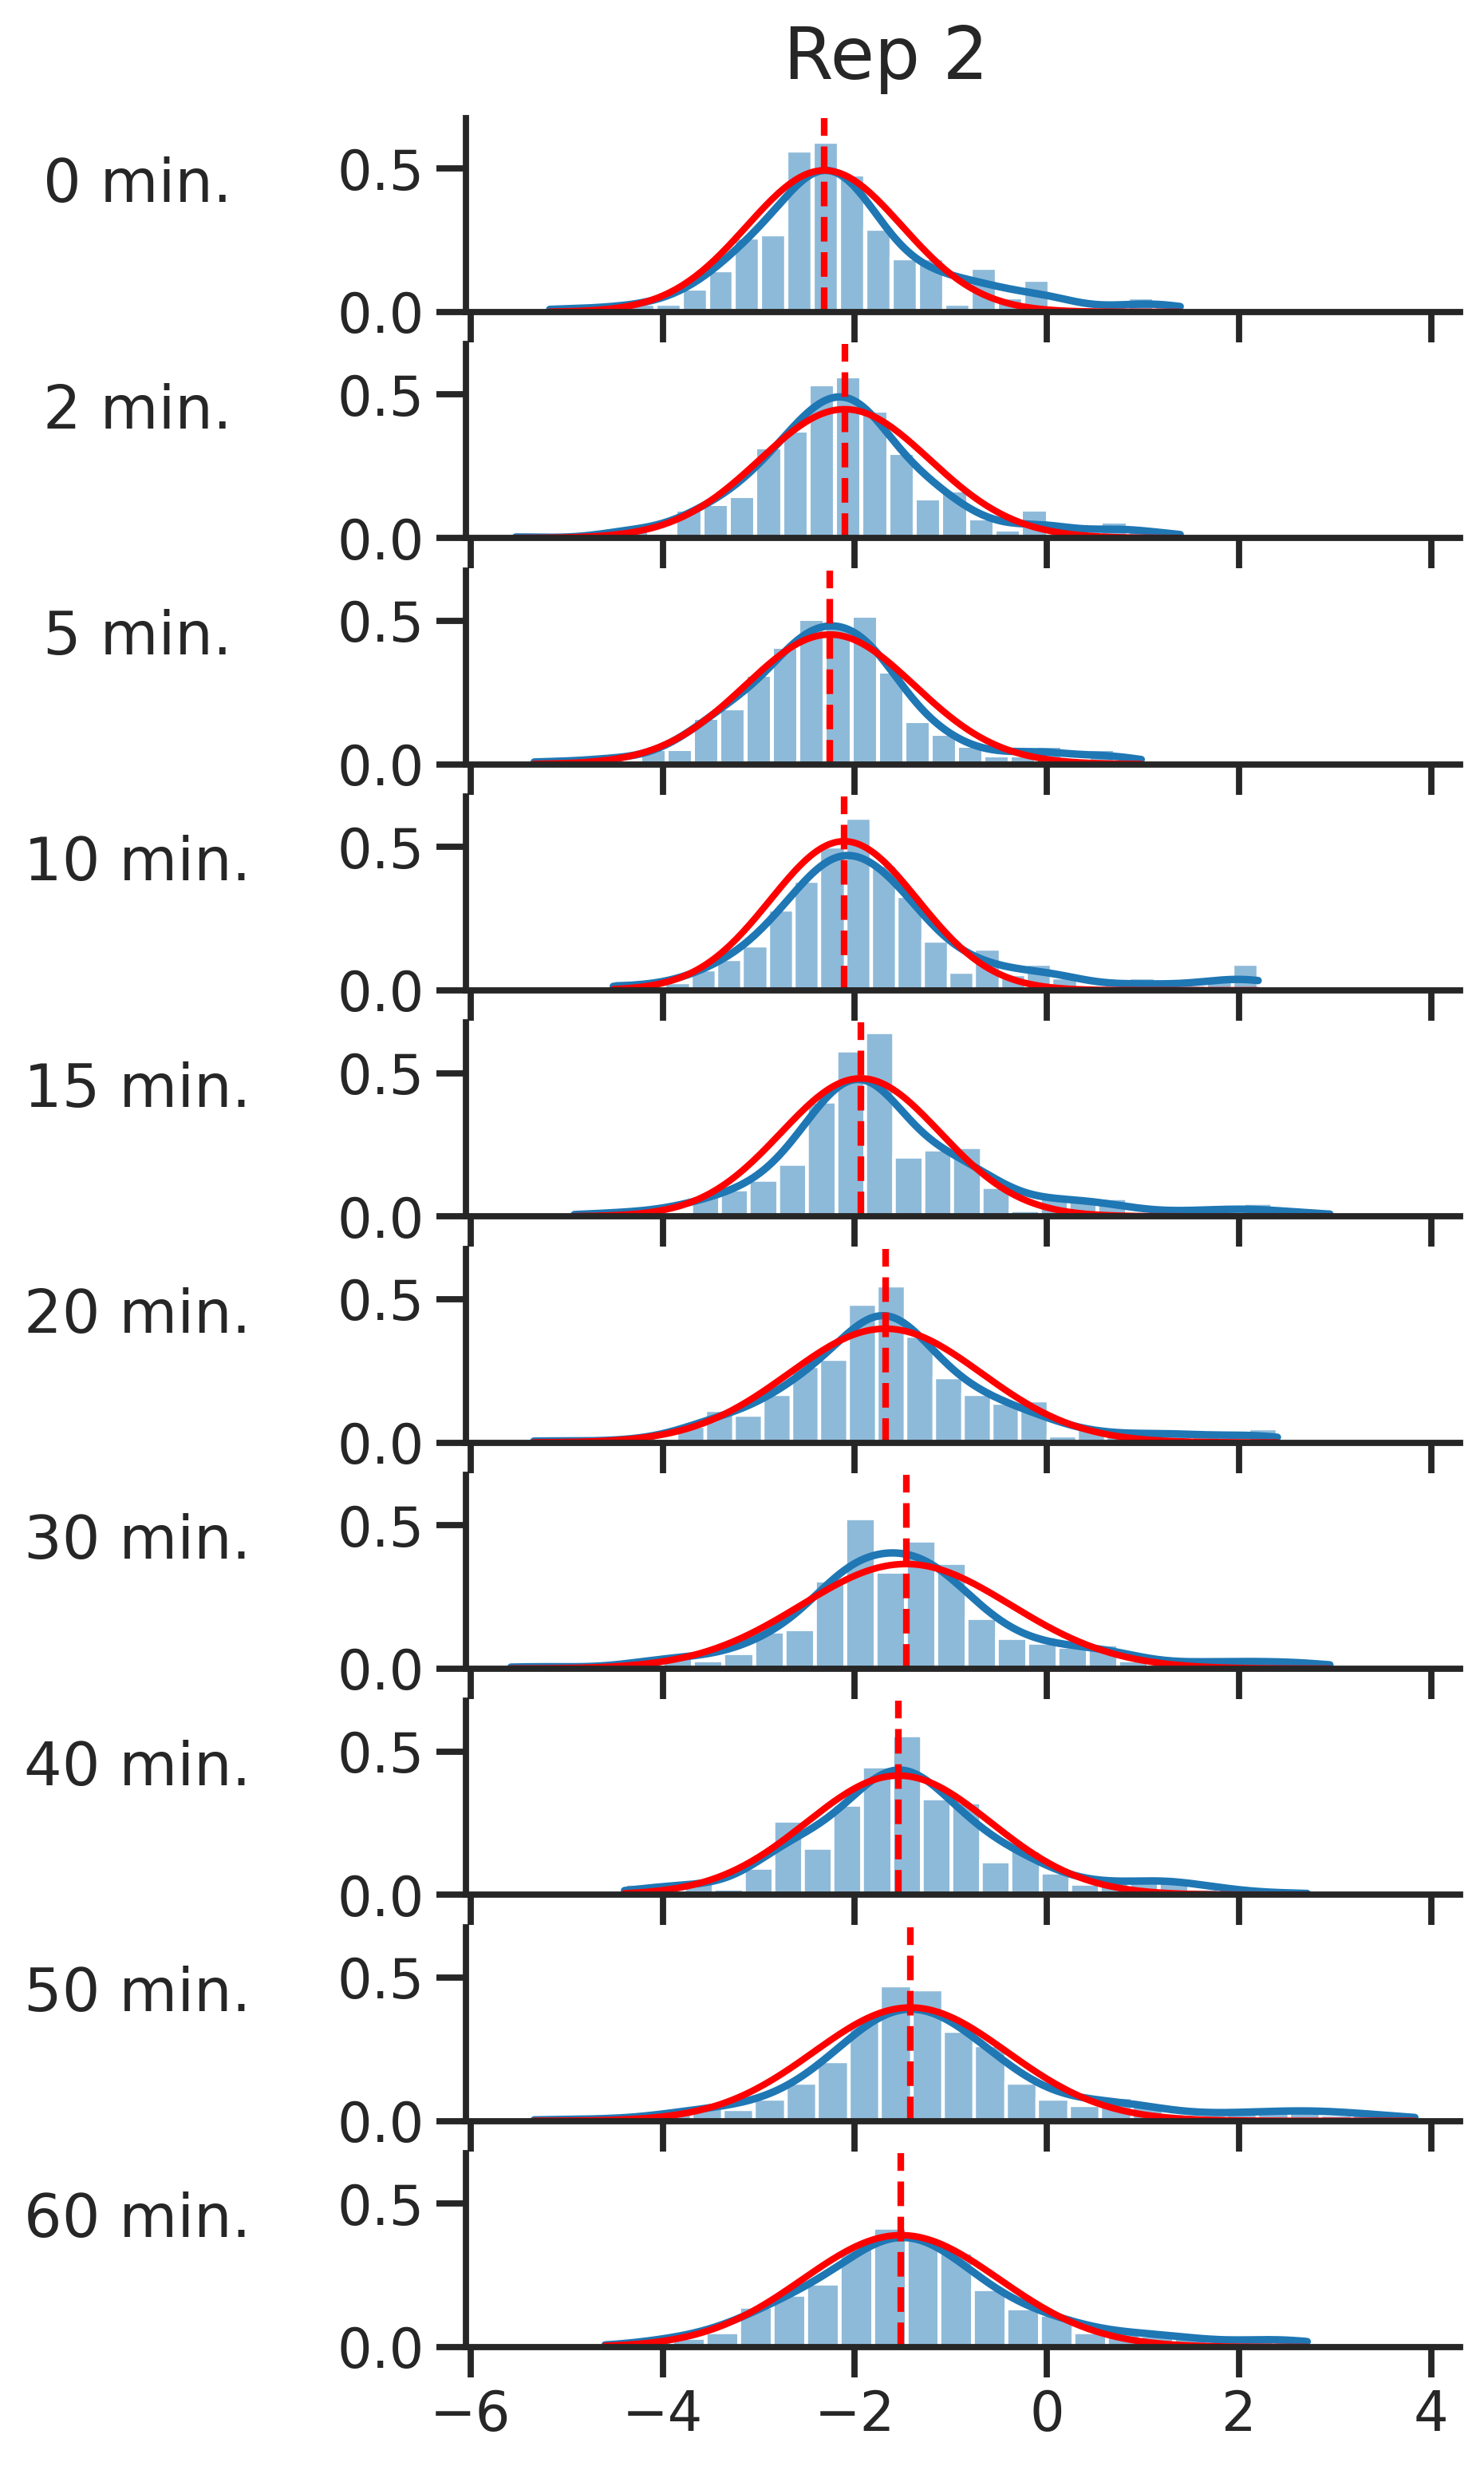

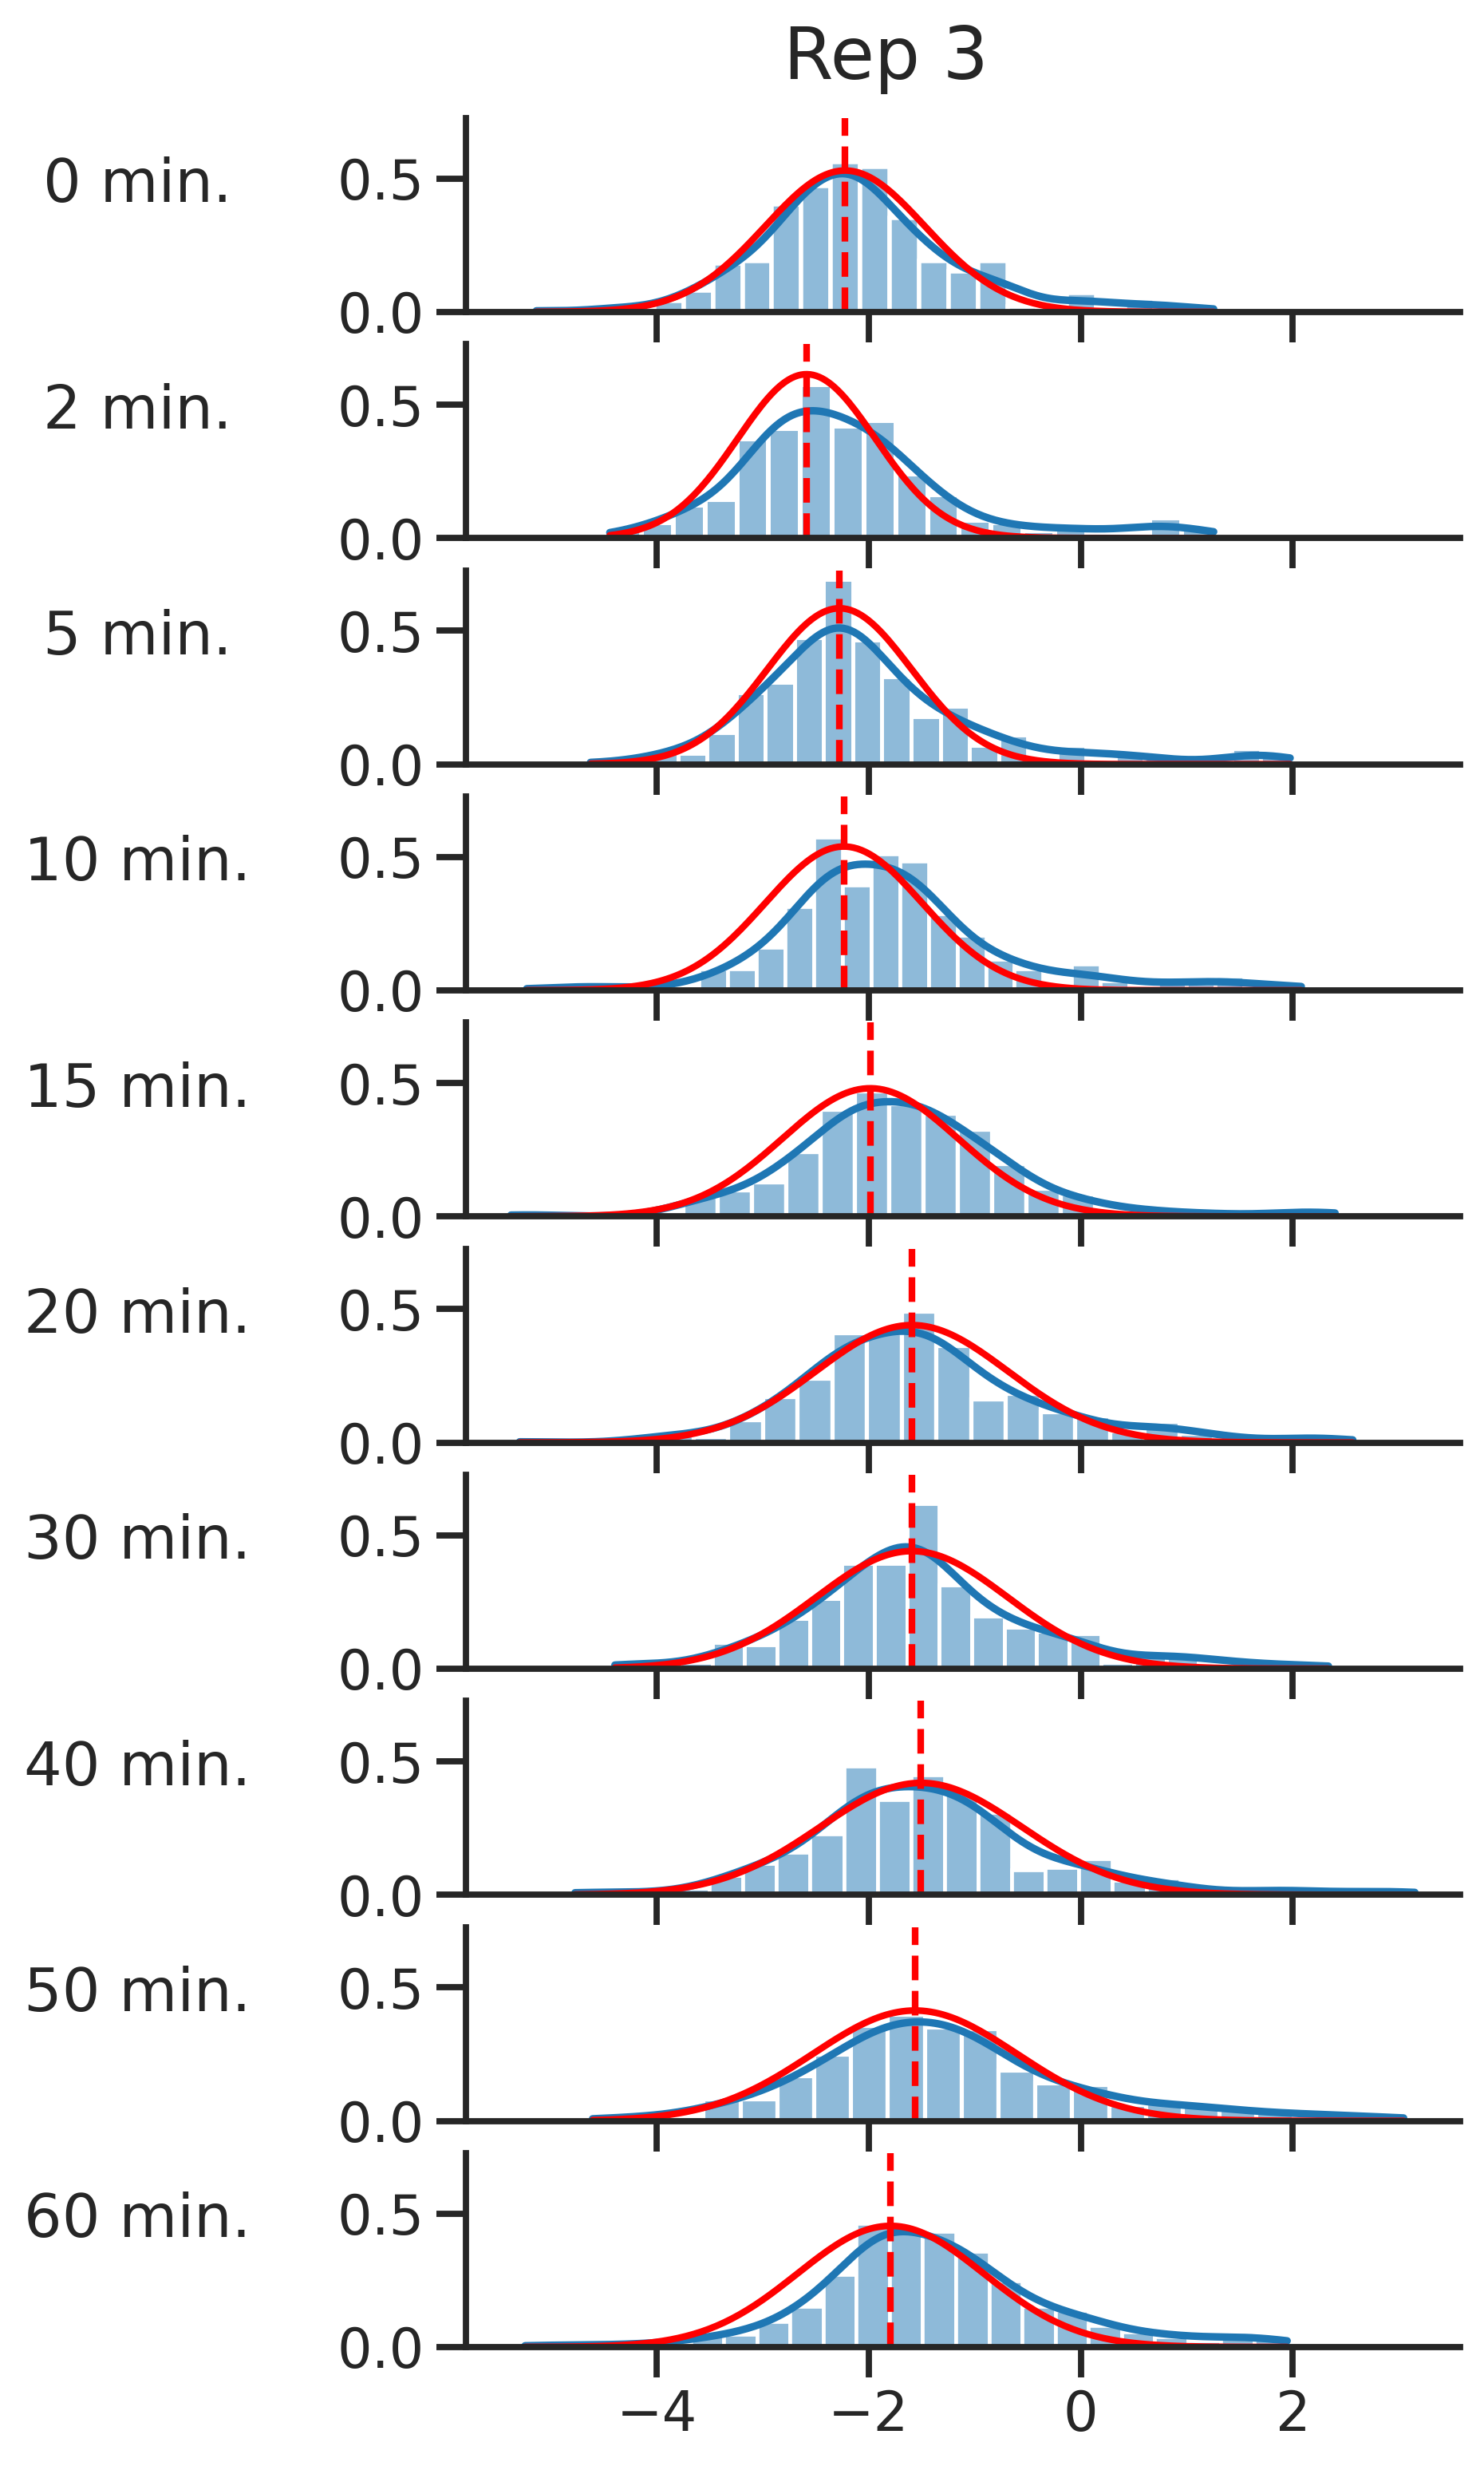

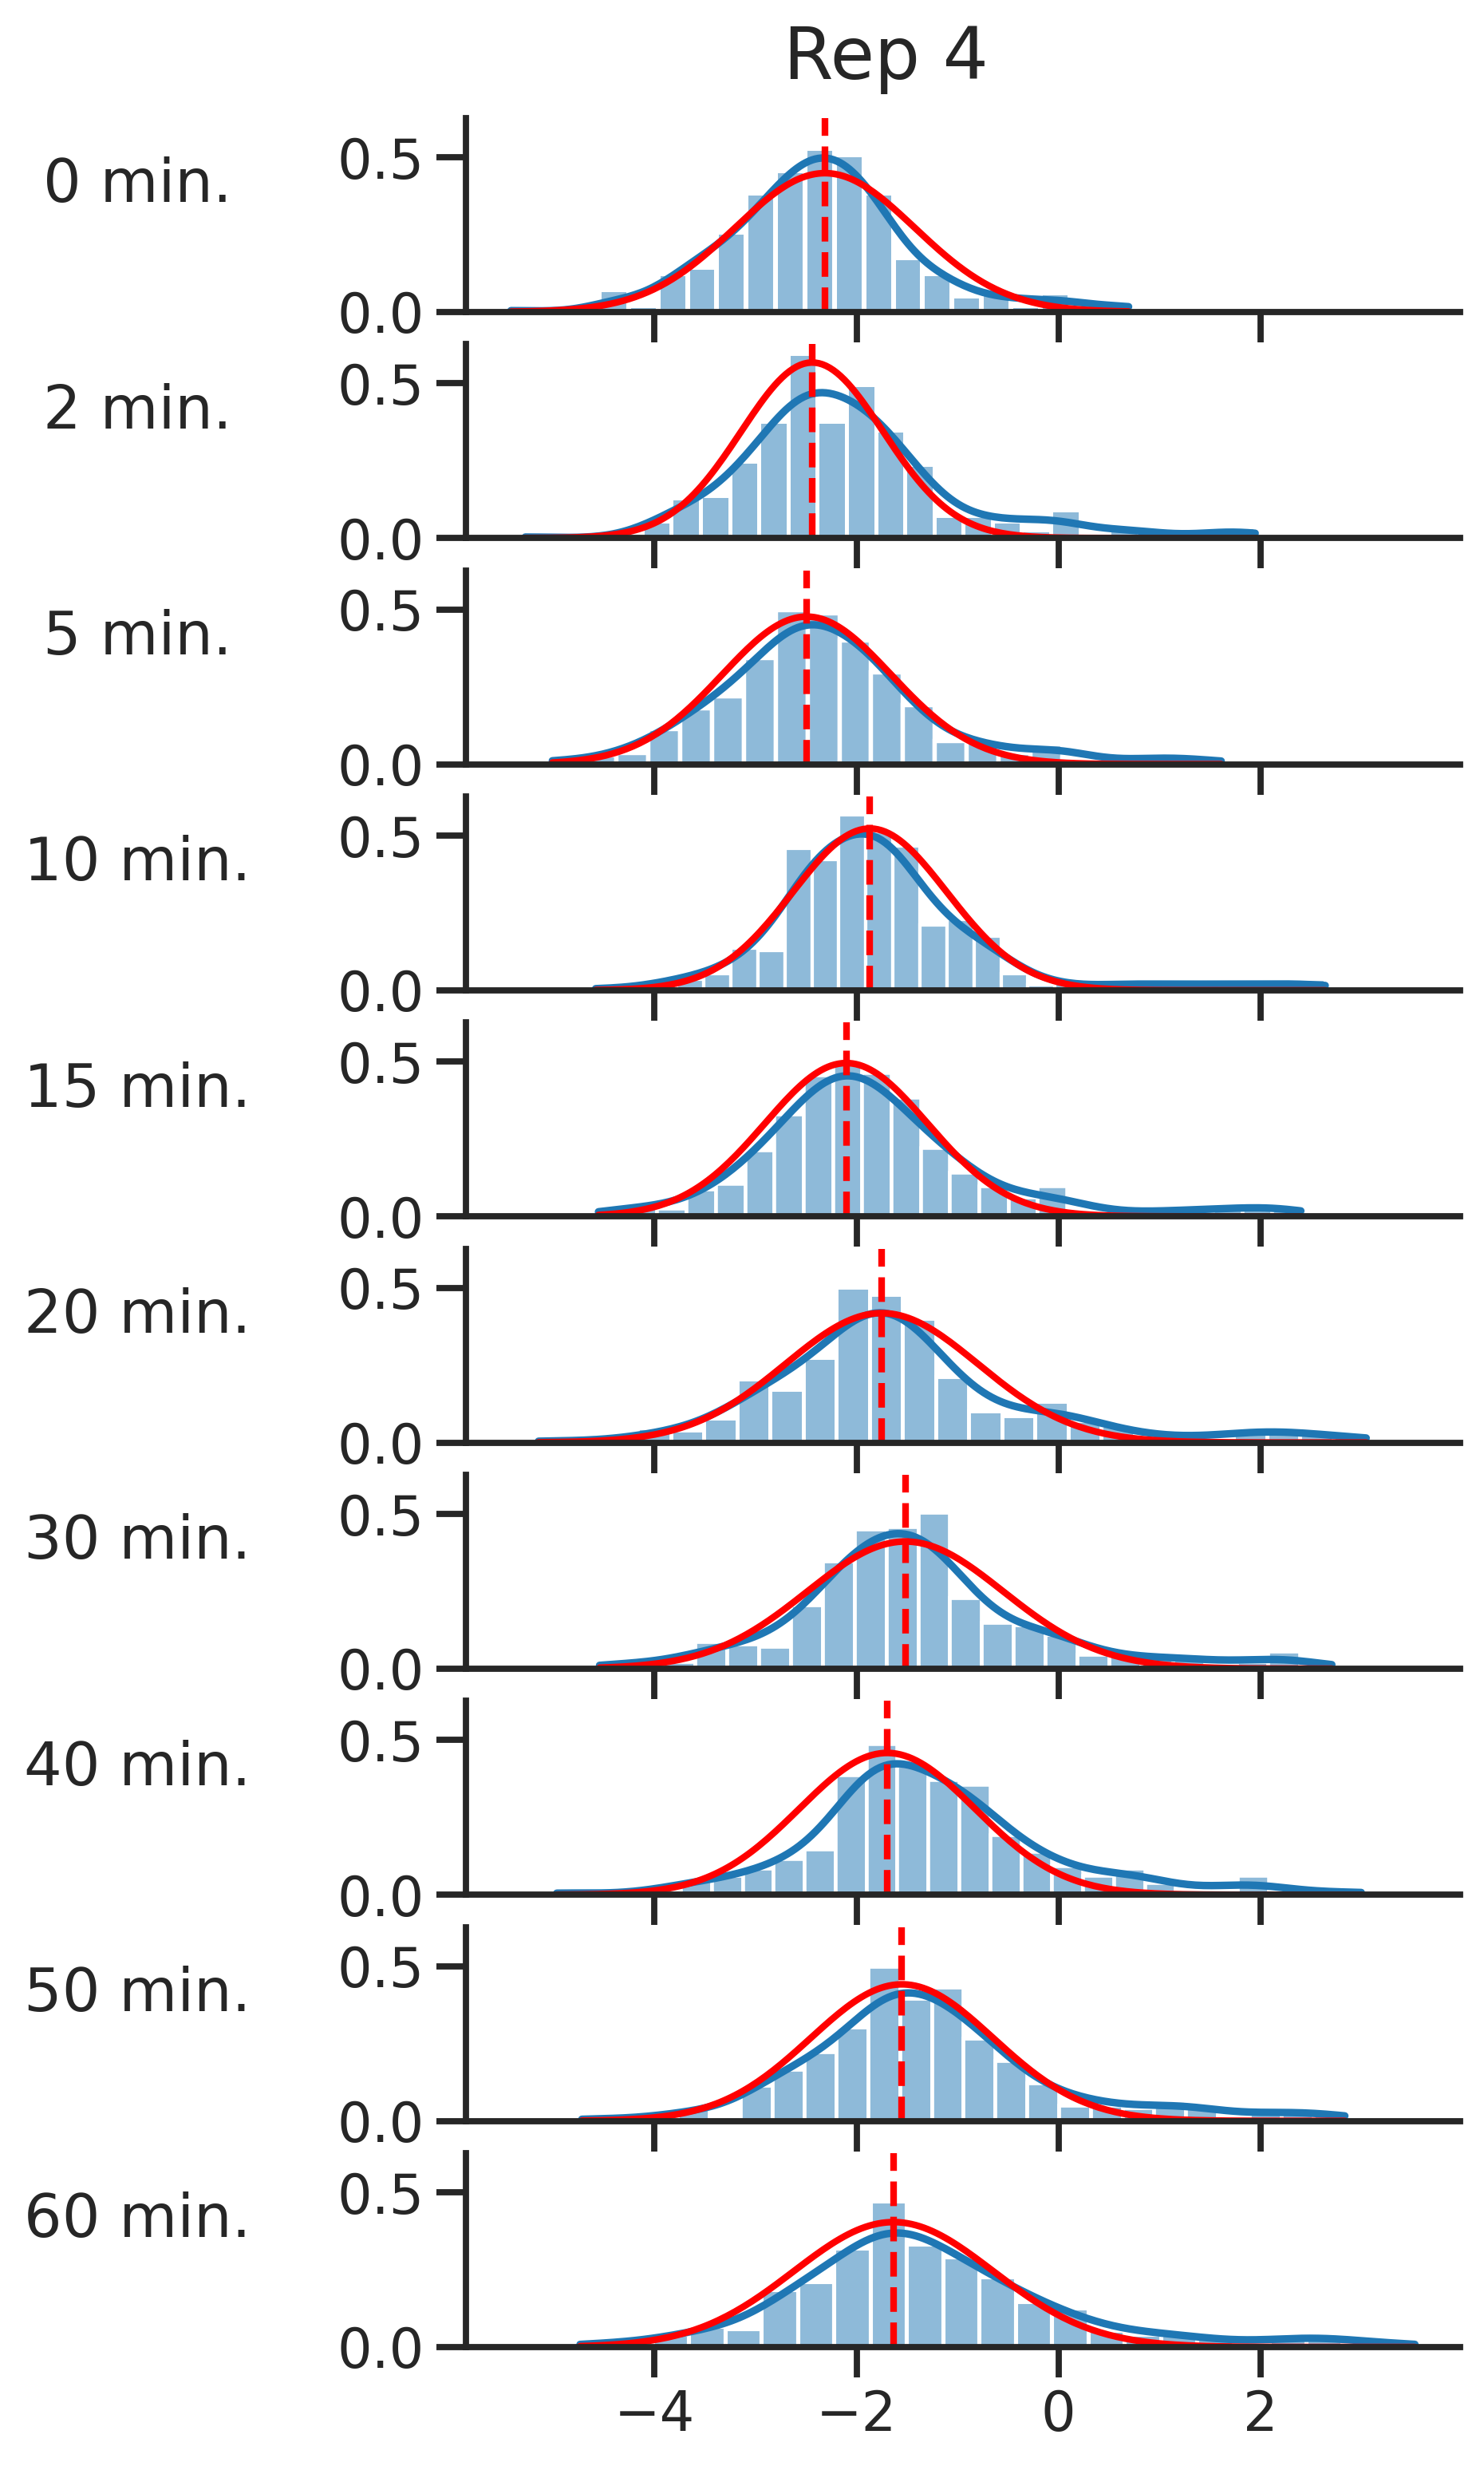

In [48]:
for target_rep in activities["rep"].unique():
    rep_keys = [(rep, time) for (rep, time) in cached_fits.keys() if rep == target_rep]
    rep_keys = sorted(rep_keys, key=lambda x: x[1])  # sort by time

    nrows = len(rep_keys)
    fig, axes = plt.subplots(nrows, 1, figsize=(6, nrows * 1), dpi=300, sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    fig.suptitle(f"Rep {target_rep}", fontsize='large', y = 1.01, x = 0.6)

    for ax, (rep, time) in zip(axes, rep_keys):
        mu, sigma, truncated, df = cached_fits[(rep, time)]
        sns.histplot(truncated, ax=ax, stat='density', kde=True)
        ax.axvline(mu, color='red', linestyle='dashed', lw=2)
        x = np.linspace(min(truncated), max(truncated), 200)
        ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)
        y_max = max(p.get_height() for p in ax.patches)
        # ax.set_ylim(0, y_max * 1.15)
        ax.set_ylabel(f"{time} min.", fontsize='medium', rotation = 0, labelpad = 60)
        ax.set_xlabel("")

    plt.tight_layout(pad = 0)
    sns.despine()
    plt.show()

In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, kstest

def fit_inactive_gaussian_progressive(df, ax=None):

    scores = np.array(df["score"])
    search_ceiling = np.percentile(scores, 99)
    truncated = scores[scores < search_ceiling]

    s = np.sort(truncated)

    best_score = np.inf
    best_mu = None
    best_sigma = None
    best_idx = None

    min_points = max(50, int(len(s)*0.02))

    # progressively expand window from left
    for i in range(min_points, len(s)):

        window = s[:i]
        mu = np.mean(window)
        sigma = np.std(window)

        if sigma == 0:
            continue

        ks_stat, _ = kstest(window, 'norm', args=(mu, sigma))

        if ks_stat < best_score:
            best_score = ks_stat
            best_mu = mu
            best_sigma = sigma
            best_idx = i

    peak_location = best_mu

    # mirror left side around peak
    left_of_peak = s[s < peak_location]
    mirrored = np.concatenate([left_of_peak, 2 * peak_location - left_of_peak])

    mu = peak_location
    sigma = np.std(mirrored)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5,3), dpi=150)

    sns.histplot(truncated, ax=ax, stat="density", bins=80, kde = True)
    ax.axvline(mu, color="red", linestyle="dashed", lw=2, label=f"peak={mu:.3f}")

    x = np.linspace(min(truncated), max(truncated), 500)
    ax.plot(x, norm.pdf(x, mu, sigma), "r-", lw=2)

    ax.legend(fontsize=8)
    ax.set_title(f"rep={df['rep'].iloc[0]}, time={df['time'].iloc[0]}", fontsize=8)

    df = df.copy()
    df["z-score"] = (df["score"] - mu) / sigma

    return df

,AD_BC,RPTR_BC,rep,time,count_directional_AD,count_directional_RT,score,seq,z-score
0,AAAACAAACCC,AGAATTAAATAAAA,2,5,127,5,-3.234749,,-1.054506
1,AAAACCGTTAC,TTCCATGATAGCAG,2,5,27,1,-3.295837,,-1.125515
2,AAAAGAACGAC,TTGGTATTTAATCA,2,5,47,8,-1.770706,,0.647316
3,AAAATATACGT,ACCTATATATTACC,2,5,3,5,0.510826,,3.299396
4,AAAGTTATCGA,ACCTTAATTTCAGA,2,5,91,6,-2.719100,,-0.455109
...,...,...,...,...,...,...,...,...,...
342,TTTACTAATTT,TTCCCCACGGGCAT,2,5,95,3,-3.455265,,-1.310836
343,TTTAGCAAAAA,CGTTTATACGATGA,2,5,36,1,-3.583519,,-1.459921
344,TTTATAGCCAT,TCTAGCGTGGAGAA,2,5,19,1,-2.944439,,-0.717046
345,TTTGTATAGTT,GCTATACCATAATG,2,5,33,3,-2.397895,,-0.081737


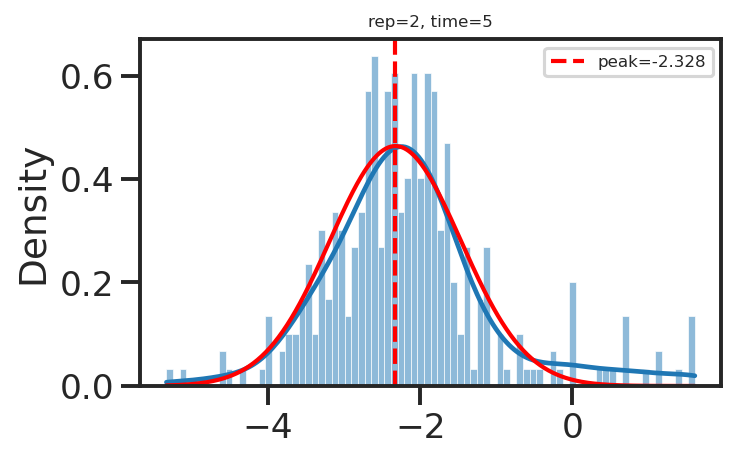

In [55]:
fit_inactive_gaussian_progressive(activities_by_time_rep[(2,5)])